

For this analysis, we're modeling a UBE in Bellingham



In [1048]:
# Import utility functions
import sys
import pandas as pd
import geopandas as gpd
sys.path.append('..')  # Add parent directory to path

# Import from local utility modules
from lvt_utils import ensure_geodataframe

print("✅ Utility functions imported from lvt_utils")


✅ Utility functions imported from lvt_utils


In [1049]:
# Import all required modules and functions
from cloud_utils import get_feature_data, get_feature_data_with_geometry
from lvt_utils import (model_split_rate_tax, calculate_current_tax, model_full_building_abatement, 
                       model_stacking_improvement_exemption, categorize_property_type, extract_date_from_filename)
from census_utils import (get_census_data, get_census_blockgroups_shapefile, get_census_data_with_boundaries, 
                          match_to_census_blockgroups, calculate_median_percentage_by_quintile, 
                          match_parcels_to_demographics, create_demographic_summary)
from viz import (create_scatter_plot, plot_comparison, calculate_correlations, weighted_median, 
                 create_quintile_summary, plot_quintile_analysis, create_property_category_chart, 
                 create_map_visualization, calculate_block_group_summary, filter_data_for_analysis)

scrape_data = 0

## Step 1: Getting the Data


In [1050]:
import requests
import pandas as pd

def get_bellingham_parcels():
    """
    Fetches all parcels in Bellingham from Whatcom County's ArcGIS REST feature service,
    returns a Pandas DataFrame with all parcel attributes (geometry is included as JSON, not converted).
    """
    BASE_URL = "https://gis.whatcomcounty.us/arcgis/rest/services/Applications/ParcelViewerAddOnData/MapServer/8/query"
    where_clause = "situs_city = 'BELLINGHAM'"  
    page_size = 1000  # MaxRecordCount from service
    offset = 0
    all_attrs = []

    while True:
        params = {
            "where": where_clause,
            "outFields": "*",
            "returnGeometry": "true",  # still grab geometry for now, but don't convert
            "orderByFields": "OBJECTID",
            "resultOffset": offset,
            "resultRecordCount": page_size,
            "f": "json",
        }
        resp = requests.get(BASE_URL, params=params)
        resp.raise_for_status()
        data = resp.json()

        features = data.get("features", [])
        print(f"Fetched {len(features)} features at offset {offset}")

        if not features:
            break

        for f in features:
            rec = f.get("attributes", {}).copy()
            rec["geometry"] = f.get("geometry")
            all_attrs.append(rec)

        if len(features) < page_size:
            break

        offset += page_size

    print(f"Total Bellingham parcels downloaded: {len(all_attrs)}")

    if not all_attrs:
        raise RuntimeError("No parcels were fetched from the service.")

    # Build plain DataFrame for now
    df = pd.DataFrame(all_attrs)
    return df


In [1051]:

import os
from datetime import datetime
import glob

# Directory to save/load data
data_dir = "data/bellingham"
os.makedirs(data_dir, exist_ok=True)



if scrape_data == 1:
    # Fetch the parcel data for Bellingham with geometry
    parcel_civic_df = get_bellingham_parcels()

    # Save with geometry to parquet, with current date
    today_str = datetime.now().strftime("%Y_%m_%d")
    out_path = os.path.join(data_dir, f"bellingham_parcels_{today_str}.parquet")
    parcel_civic_df.to_parquet(out_path, index=False)
    print(f"Saved new scrape to {out_path}")
else:
    # Find the most recent Bellingham parcel parquet file in the data_dir
    files = glob.glob(os.path.join(data_dir, "bellingham_parcels_*.parquet"))
    if not files:
        raise FileNotFoundError("No previously scraped parcel files found in data/bellingham/")
    # Sort files by date in filename
    files_sorted = sorted(
        files,
        key=lambda x: datetime.strptime(
            os.path.basename(x).replace("bellingham_parcels_", "").replace(".parquet", ""),
            "%Y_%m_%d"
        ),
        reverse=True
    )
    latest_file = files_sorted[0]
    print(f"Loading most recent scrape: {latest_file}")
    parcel_civic_df = pd.read_parquet(latest_file)

# Ensure parcel_civic_df is a proper GeoDataFrame
#parcel_civic_df = ensure_geodataframe(parcel_civic_df)
#print(f"✅ Parcel data loaded as {type(parcel_civic_df).__name__} with CRS: {parcel_civic_df.crs}")



Loading most recent scrape: data/bellingham/bellingham_parcels_2025_11_29.parquet


In [1052]:
parcel_civic_df.head()


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry
0,1,3802300322850000,53502,380230032285,380230,032285,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3109,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1113,RES 3 BDRM,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-R SEG B-A,None,None,5.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,55626.828125,2108.477632,"{'rings': [[[-13649632.083 6233124.9916], [..."
1,2,3802300403100000,53505,380230040310,380230,040310,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3105,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1150,MH RP-onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-Q SEG B-A,None,None,3.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,36951.164062,1351.217148,"{'rings': [[[-13649196.4179 6233478.7347], [..."
2,3,3802300503310000,53506,380230050331,380230,050331,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,None,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2001,502 R L,None,None,None,None,9110,RESIDENTIAL,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-P SEG B-A,None,None,3.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,47635.406250,1541.042385,"{'rings': [[[-13649171.0777 6233500.5669], [..."
3,4,3802300553440000,53507,380230055344,380230,055344,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3147,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR5A,RES RURAL 1 DU/5AC,2060,502 R L F8,None,None,None,None,1153,MH RP(2+)onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-O SEG B-A,None,None,5.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES

In [1053]:
import json
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# parcel_civic_df already exists

def esri_rings_to_geom(geom):
    """
    Convert an Esri JSON geometry (or similar) into a shapely Polygon/MultiPolygon.
    Handles:
      - dicts like {'rings': [...]}
      - direct rings arrays/lists
      - JSON strings
    """
    # Empty / NaN
    if geom is None or (isinstance(geom, float) and pd.isna(geom)):
        return None

    # If it's already a shapely geometry, just return it
    if isinstance(geom, (Polygon, MultiPolygon)):
        return geom

    # If it's a JSON string, parse it
    if isinstance(geom, str):
        geom = json.loads(geom)

    # Get rings from dict or treat value as rings directly
    if isinstance(geom, dict) and "rings" in geom:
        rings = geom["rings"]
    else:
        rings = geom

    # Convert possible numpy array -> Python list
    if hasattr(rings, "tolist"):
        rings = rings.tolist()

    # Guard against empty
    if len(rings) == 0:
        return None

    # Simple case: one polygon
    if len(rings) == 1:
        return Polygon(rings[0])

    # Try shell + holes; if that fails, fall back to MultiPolygon
    try:
        shell = rings[0]
        holes = rings[1:] if len(rings) > 1 else None
        return Polygon(shell, holes)
    except Exception:
        polys = [Polygon(r) for r in rings]
        return MultiPolygon(polys)

# 1. Build GeoDataFrame from the geometry column
parcel_gdf = gpd.GeoDataFrame(
    parcel_civic_df.copy(),
    geometry=parcel_civic_df["geometry"].apply(esri_rings_to_geom),
    crs="EPSG:3857"   # likely Web Mercator; change if your source CRS differs
)

# 2. Reproject to a standard US/web CRS (WGS84 lon/lat)
parcel_civic_df = parcel_gdf.to_crs("EPSG:4326")



In [1054]:
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.errors import GEOSException

# Compute percent of rows that intersect more than 0.01% of their geometries,
# and print property_use_description counts for intersected parcels
def intersection_percent_and_usage_counts(gdf, threshold=0.0001):
    n = len(gdf)
    count_intersected = 0
    intersected_indices = []
    # For speed, use bounding box spatial index first
    sindex = gdf.sindex

    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        possible_matches_index = list(sindex.intersection(geom.bounds))
        # Remove self from possible matches
        possible_matches_index = [i for i in possible_matches_index if i != idx]
        intersects = False
        for other_idx in possible_matches_index:
            other_geom = gdf.iloc[other_idx].geometry
            if other_geom is None or other_geom.is_empty:
                continue
            if not geom.intersects(other_geom):
                continue
            try:
                # Wrap intersection in try/except to catch TopologyException
                inter = geom.intersection(other_geom)
            except (GEOSException, Exception) as e:
                continue
            if inter.is_empty:
                continue
            try:
                frac = inter.area / geom.area
            except Exception:
                continue
            if frac > threshold:
                intersects = True
                break
        if intersects:
            count_intersected += 1
            intersected_indices.append(idx)
    percent = 100 * count_intersected / n if n > 0 else 0
    print(f"Percent of records that intersect another geometry by more than {threshold*100:.3f}% of their area: {percent:.2f}%")
    
    # Print counts of property_use_description for intersected parcels
    if "property_use_description" in gdf.columns:
        desc_counts = gdf.loc[intersected_indices, "property_use_description"].value_counts(dropna=False)
        print("\nproperty_use_description counts for intersected parcels:")
        print(desc_counts)
    else:
        print("'property_use_description' column not found in the dataframe.")
    return percent, intersected_indices

# Run function on our parcel_civic_df and get indices of intersecting parcels
percent_intersected, intersected_indices = intersection_percent_and_usage_counts(parcel_civic_df, threshold=0.01)



Percent of records that intersect another geometry by more than 1.000% of their area: 15.99%

property_use_description counts for intersected parcels:
property_use_description
CONDOMINIUMS           4343
MH IO-inPK             1143
STOR CONDOS             420
RES 3 BDRM              269
MH RP-onAC              244
RET/OFF CNDO            158
RM 99+ UNITS            149
RM 68 UNITS             137
M/H CONDO LND           124
RES 2 BDRM              119
M/H PK 94 SP             95
CONDO-NOT RES            83
HANGAR CONDO             82
MIX U CONDOS             74
RESIDENTIAL              71
MED CONDOS               68
M/H IN CONDO PP          58
MH RP(2+)onAC            41
ZERO LL 2 BD             39
MARINAS                  36
OTHR WTR ARE             34
RM 31 UNITS              32
MIXED USE                29
MODLR 2 BDRM             26
MINERAL INT              26
CHURCHES                 22
ZERO LL 3 BD             21
RES 4 BDRM               21
PHONE RELAY              15
RES 1 BDRM  

In [1055]:

# ---- Condense from tax parcels to land parcels, aggregating intersected parcels ----

from shapely.ops import unary_union
from shapely.geometry.base import BaseGeometry
from shapely.errors import GEOSException

# Helper for robust union (keep from previous code)
def robust_unary_union(geoms):
    cleaned = [g for g in geoms if isinstance(g, BaseGeometry) and g is not None and not g.is_empty]
    if len(cleaned) == 0:
        return None
    try:
        return unary_union(cleaned)
    except GEOSException:
        valids = [g for g in cleaned if g.is_valid]
        if len(valids) == 0:
            return None
        try:
            return unary_union(valids)
        except GEOSException:
            from shapely.geometry import MultiPolygon, GeometryCollection, Polygon
            polys = [g for g in valids if isinstance(g, Polygon)]
            if len(polys) > 1:
                return MultiPolygon(polys)
            elif len(valids) > 1:
                return GeometryCollection(valids)
            else:
                return valids[0]
    except Exception:
        return None

sum_cols = [
    "market_land_val",
    "market_improvement_val",
    "market",
    "appraised_land_val",
    "appraised_improvement_val",
    "appraised_val_total",
    "senior_value",
    "taxable_val_total"
]

import pandas as pd

print(f"Original parcel_civic_df shape: {parcel_civic_df.shape}")

# Select intersected parcels
intersected_df = parcel_civic_df.loc[intersected_indices].copy().reset_index()
if intersected_df.empty:
    print("No intersected parcels found to condense.")
else:
    # Cluster overlapping parcels to represent "land parcel groups"
    sindex = intersected_df.sindex
    visited = set()
    clusters = []
    for int_idx, row in intersected_df.iterrows():
        if int_idx in visited:
            continue
        cluster_idxs = set([int_idx])
        check_queue = [int_idx]
        while check_queue:
            curr_idx = check_queue.pop()
            curr_geom = intersected_df.iloc[curr_idx].geometry
            possible_idxs = set(sindex.intersection(curr_geom.bounds))
            possible_idxs.discard(curr_idx)
            for other_idx in possible_idxs:
                if other_idx in cluster_idxs:
                    continue
                other_geom = intersected_df.iloc[other_idx].geometry
                if curr_geom.intersects(other_geom):
                    cluster_idxs.add(other_idx)
                    check_queue.append(other_idx)
        clusters.append(cluster_idxs)
        visited.update(cluster_idxs)

    # Aggregate info for each land parcel group (cluster of intersected parcels)
    aggregation_records = []
    for cluster in clusters:
        sub = intersected_df.iloc[list(cluster)]
        agg_sums = sub[sum_cols].sum(numeric_only=True)
        first_row = sub.iloc[0]
        record = first_row.to_dict()
        for col in sum_cols:
            record[col] = agg_sums[col]
        geoms = [geom for geom in sub.geometry if geom is not None and not geom.is_empty]
        record["geometry"] = robust_unary_union(geoms)
        aggregation_records.append(record)

    # Create df of condensed land parcels
    import geopandas as gpd
    condensed_land_gdf = gpd.GeoDataFrame(aggregation_records, geometry="geometry", crs=parcel_civic_df.crs)

    # Remove all original parcels corresponding to condensed intersected groups
    remaining_df = parcel_civic_df.drop(parcel_civic_df.index[intersected_indices])

    # Combine remaining (non-intersected, i.e., most "simple" land parcels) with our new clusters
    # For consistency, columns should align across both dataframes:
    condensed_land_gdf = condensed_land_gdf[remaining_df.columns.intersection(condensed_land_gdf.columns).tolist() + [col for col in condensed_land_gdf.columns if col not in remaining_df.columns]]
    land_parcels_gdf = pd.concat([remaining_df, condensed_land_gdf[remaining_df.columns]], ignore_index=True)
    # (if geometry is not in remaining_df.columns, add it back)
    if "geometry" not in remaining_df.columns:
        land_parcels_gdf["geometry"] = pd.concat([remaining_df["geometry"], condensed_land_gdf["geometry"]], ignore_index=True)

    # Overwrite the main dataframe in place
    old_shape = parcel_civic_df.shape
    parcel_civic_df.drop(parcel_civic_df.index, inplace=True)
    for col in land_parcels_gdf.columns:
        if col not in parcel_civic_df.columns:
            parcel_civic_df[col] = None
    for col in parcel_civic_df.columns:
        if col not in land_parcels_gdf.columns:
            parcel_civic_df.drop(col, axis=1, inplace=True)
    for col in land_parcels_gdf.columns:
        parcel_civic_df[col] = land_parcels_gdf[col]
    parcel_civic_df.geometry = land_parcels_gdf.geometry

    print(f"Condensed to land parcels. New parcel_civic_df shape: {parcel_civic_df.shape}")
    print(f"Total rows condensed (removed): {old_shape[0] - parcel_civic_df.shape[0]}")

    # Optional: show head of result
    display(parcel_civic_df.head())



Original parcel_civic_df shape: (52791, 72)
Condensed to land parcels. New parcel_civic_df shape: (46456, 72)
Total rows condensed (removed): 6335


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry
0,1,3802300322850000,53502,380230032285,380230,032285,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3109,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1113,RES 3 BDRM,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-R SEG B-A,None,None,5.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,55626.828125,2108.477632,"POLYGON ((-122.61673 48.75342, -122.61611 48.7..."
1,2,3802300403100000,53505,380230040310,380230,040310,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3105,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1150,MH RP-onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-Q SEG B-A,None,None,3.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,36951.164062,1351.217148,"POLYGON ((-122.61282 48.75551, -122.61259 48.7..."
2,3,3802300503310000,53506,380230050331,380230,050331,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,None,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2001,502 R L,None,None,None,None,9110,RESIDENTIAL,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-P SEG B-A,None,None,3.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,47635.406250,1541.042385,"POLYGON ((-122.61259 48.75564, -122.61237 48.7..."
3,4,3802300553440000,53507,380230055344,380230,055344,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3147,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR5A,RES RURAL 1 DU/5AC,2060,502 R L F8,None,None,None,None,1153,MH RP(2+)onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-O SEG B-A,None,None,5.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE 

In [1056]:

pd.set_option('display.max_columns', None)
display(parcel_civic_df.head(5))

,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry
0,1,3802300322850000,53502,380230032285,380230,032285,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3109,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1113,RES 3 BDRM,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-R SEG B-A,None,None,5.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,55626.828125,2108.477632,"POLYGON ((-122.61673 48.75342, -122.61611 48.7..."
1,2,3802300403100000,53505,380230040310,380230,040310,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3105,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2060,502 R L F8,None,None,None,None,1150,MH RP-onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-Q SEG B-A,None,None,3.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,36951.164062,1351.217148,"POLYGON ((-122.61282 48.75551, -122.61259 48.7..."
2,3,3802300503310000,53506,380230050331,380230,050331,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,None,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR1,RES RURAL 1DU/A,2001,502 R L,None,None,None,None,9110,RESIDENTIAL,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-P SEG B-A,None,None,3.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE BIA-RES 107 JURISDI...,2579 KWINA RD,UNITED STATES DEPT OF INTERIOR BIA-RES 107 JUR...,911 NE 11TH AVE,None,0,0,NaN,NaN,47635.406250,1541.042385,"POLYGON ((-122.61259 48.75564, -122.61237 48.7..."
3,4,3802300553440000,53507,380230055344,380230,055344,0000,R,70777,LUMMI TRIBAL REALTY OFFICE,BIA-RES 107,JURISDICTION PROPERTIES,2579 KWINA RD,BELLINGHAM,WA,98226-9278,None,112701,UNITED STATES DEPT OF INTERIOR,BIA-RES 107,JURISDICTION PROPERTIES,911 NE 11TH AVE,PORTLAND,OR,97232-4169,None,3147,None,LUMMI SHORE RD,None,BELLINGHAM,WA,None,None,RR5A,RES RURAL 1 DU/5AC,2060,502 R L F8,None,None,None,None,1153,MH RP(2+)onAC,,EX,INDIAN,RMAPPRJ-BIA TRACT 107-59-O SEG B-A,None,None,5.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,https://property.whatcomcounty.us/propertyacce...,LUMMI TRIBAL REALTY OFFICE 

### Pull tax levy data

In [1057]:
import time
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os

# --- 1. Pick one prop_id per tax_code_area -----------------------------------

tax_col = "tax_area_number"
prop_col = "prop_id"

sample_props = (
    parcel_civic_df
    .dropna(subset=[prop_col])
    .groupby(tax_col)[prop_col]
    .first()
)

# --- 2. Helpers --------------------------------------------------------------

BASE_URL = "https://property.whatcomcounty.us/propertyaccess/Property.aspx"

def parse_currency(s):
    """Turn '$1,857' or '$0.04' into float, or NaN if blank."""
    if not s:
        return np.nan
    s = s.replace("$", "").replace(",", "").strip()
    if s == "":
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def normalize_prop_id(pid):
    """
    Make sure prop_id looks like 39540 not 39540.0.
    Keep strings as-is (trimmed), cast floats/ints to int string.
    """
    if isinstance(pid, (int, np.integer)):
        return str(pid)
    if isinstance(pid, float):
        if np.isnan(pid):
            return None
        return str(int(pid))
    # fallback: string
    s = str(pid).strip()
    # if it looks like '39540.0', cast to int
    try:
        if "." in s:
            return str(int(float(s)))
    except ValueError:
        pass
    return s

def fetch_levy_table(prop_id, year=2023, session=None, sleep_sec=0.5, debug=False):
    """
    Fetch levy table for a single prop_id/year from Whatcom County.
    Returns a DataFrame with one row per levy line.
    """
    if session is None:
        session = requests.Session()

    pid = normalize_prop_id(prop_id)
    if pid is None:
        return pd.DataFrame()

    params = {"cid": 0, "year": year, "prop_id": pid}
    resp = session.get(BASE_URL, params=params)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")

    # Be explicit: table inside the taxingJurisdictionDetails div
    div = soup.find("div", id="taxingJurisdictionDetails")
    if div is None:
        if debug:
            print(f"No taxingJurisdictionDetails div for prop_id {pid}")
        return pd.DataFrame()

    table = div.find("table", {"class": "tableData"})
    if table is None:
        if debug:
            print(f"No tableData table in taxingJurisdictionDetails for prop_id {pid}")
        return pd.DataFrame()

    rows = []
    trs = table.find_all("tr")

    # Skip header row (index 0)
    for tr in trs[1:]:
        tds = [td.get_text(strip=True) for td in tr.find_all("td")]
        if len(tds) < 6:
            continue

        levy_code, desc, levy_rate, appraised, taxable, est_tax = tds[:6]

        # Skip summary/footer rows that don't have a levy code
        if levy_code == "" and (
            "Total Tax Rate" in desc
            or "Taxes w/Current Exemptions" in desc
            or "Taxes w/o Exemptions" in desc
        ):
            continue

        # Ignore completely blank rows
        if levy_code == "" and desc == "" and levy_rate == "":
            continue

        rows.append(
            {
                "levy_code": levy_code,
                "taxing_jurisdiction": desc,
                "levy_rate": float(levy_rate) if levy_rate else np.nan,
                "appraised_value": parse_currency(appraised),
                "taxable_value": parse_currency(taxable),
                "estimated_tax": parse_currency(est_tax),
            }
        )

    time.sleep(sleep_sec)
    return pd.DataFrame(rows)

# --- 3. Choose data loading/scraping mode -------------------------------------


bellingham_data_dir = "data/bellingham"
os.makedirs(bellingham_data_dir, exist_ok=True)
bellingham_taxing_path = os.path.join(bellingham_data_dir, "taxing_df.parquet")

if scrape_data == 1:
    session = requests.Session()
    all_levies = []
    for tca, prop_id in sample_props.items():
        try:
            df = fetch_levy_table(prop_id=prop_id, year=2023, session=session, debug=True)
            if df.empty:
                print(f"No levy data for tax_code_area {tca} (prop_id {prop_id})")
                continue

            df[tax_col] = tca
            df[prop_col] = normalize_prop_id(prop_id)
            all_levies.append(df)

        except Exception as e:
            print(f"Failed for tax_code_area {tca} (prop_id {prop_id}): {e}")

    if all_levies:
        taxing_df = pd.concat(all_levies, ignore_index=True)
    else:
        taxing_df = pd.DataFrame(
            columns=[
                tax_col,
                prop_col,
                "levy_code",
                "taxing_jurisdiction",
                "levy_rate",
                "appraised_value",
                "taxable_value",
                "estimated_tax",
            ]
        )
    # Save to parquet in data/bellingham/
    taxing_df.to_parquet(bellingham_taxing_path, index=False)

else:
    # Read from parquet file in data/bellingham/
    if os.path.exists(bellingham_taxing_path):
        taxing_df = pd.read_parquet(bellingham_taxing_path)
    else:
        print(f"File not found: {bellingham_taxing_path}. No taxing_df loaded.")
        taxing_df = pd.DataFrame(
            columns=[
                tax_col,
                prop_col,
                "levy_code",
                "taxing_jurisdiction",
                "levy_rate",
                "appraised_value",
                "taxable_value",
                "estimated_tax",
            ]
        )

taxing_df.head()


,levy_code,taxing_jurisdiction,levy_rate,appraised_value,taxable_value,estimated_tax,tax_area_number,prop_id
0,BHAH,CITY OF BELLINGHAM AFF HSG,0.059465,600.0,600.0,0.04,0100,20474
1,BHFP,CITY OF BELLINGHAM FIRE PENSION,0.125102,600.0,600.0,0.08,0100,20474
2,BHGEN,CITY OF BELLINGHAM GENERAL FUND,0.769772,600.0,600.0,0.46,0100,20474
3,BHGW4,CITY OF BELLINGHAM GREENWAYS IV,0.001448,600.0,600.0,0.00,0100,20474
4,BHGW5,CITY OF BELLINGHAM GREENWAYS V,0.410743,600.0,600.0,0.25,0100,20474


In [1058]:
print("Tax area  value counts in parcel_civic_df:")
print(taxing_df['levy_code'].value_counts(dropna=False).to_string())


Tax area  value counts in parcel_civic_df:
levy_code
WCER          60
WA2           60
WCEMS         60
WCVR          60
CFL           60
FCZDL         60
PTBOND        60
PTGEN         60
PTRDA         60
WCDD          60
WCCT          60
WCCI          60
WCCE          60
WA1           60
RLIBGEN       55
RDDIV         52
RDGEN         52
SD501TRV      24
SD501CP       24
SD501B        24
SD501MO       24
SD502B        12
SD507MO       12
SD507CP       12
FD004EMS      12
SD502MO       12
SD502CP       12
SD507B        12
SD505MO       10
SD505CP       10
SD505B        10
LWWSB          6
FD007BOND      6
FD007EXP       6
FD021AX13      6
FD021EXP       6
CEM006         6
FD004EXP       6
FD004CI        6
FD004BOND      6
CEM004         5
FD052EXP       5
BHAH           5
FD052CI        5
AHBH13         5
BHGEN          5
BHRDA          5
FD052B         5
BHGW5          5
BHGW4          5
BHFP           5
FD008MO        4
FD008EXP       4
W007B          4
FERNCE         3
FERN13BOND  

In [1059]:
print("Tax area  value counts in parcel_civic_df:")
print(taxing_df['taxing_jurisdiction'].value_counts(dropna=False).to_string())


Tax area  value counts in parcel_civic_df:
taxing_jurisdiction
COUNTY ELECTION RESERVE                    60
STATE SCHOOL PART 2                        60
WHATCOM COUNTY EMS                         60
COUNTY VETERANS RELIEF                     60
CONSERVATION FUTURES                       60
FLOOD CONTROL ZONE                         60
PORT OF BELLINGHAM GO BOND                 60
PORT OF BELLINGHAM GENERAL FUND            60
PORT OF BELLINGHAM RDA                     60
COUNTY DEVELOPMENTAL DISABILITY            60
COUNTY MENTAL HEALTH                       60
CHILDRENS INITIATIVE                       60
COUNTY CURRENT EXPENSE                     60
STATE SCHOOL PART 1                        60
RURAL LIBRARY                              55
COUNTY ROAD DIVERSION                      52
COUNTY ROAD FUND                           52
BELLINGHAM #501 TRANSPORTATION             24
BELLINGHAM SCHOOL #501 CAPITAL PROJECTS    24
BELLINGHAM SCHOOL #501 BOND                24
BELLINGHAM SCHOOL

In [1060]:

print(parcel_civic_df.columns)


Index(['OBJECTID', 'geo_id', 'prop_id', 'TTRRSSXXXYYY', 'TTRRSS', 'XXXYYY',
       'AUX', 'property_type', 'tax_payer_id', 'tax_payer_name',
       'tax_payer_line1', 'tax_payer_line2', 'tax_payer_line3',
       'tax_payer_city', 'tax_payer_state', 'tax_payer_zip',
       'tax_payer_country', 'title_owner_id', 'title_owner_name',
       'title_owner_line1', 'title_owner_line2', 'title_owner_line3',
       'title_owner_city', 'title_owner_state', 'title_owner_zip',
       'title_owner_country', 'situs_num', 'situs_street_prefix',
       'situs_street', 'situs_unit', 'situs_city', 'situs_state',
       'situs_building_num', 'situs_sub_num', 'zoning', 'zoning_description',
       'tax_area_number', 'tax_area_description', 'subdv_cd',
       'subdv_description', 'lot', 'block', 'property_use_cd',
       'property_use_description', 'lien_type', 'exmpt_type_cd',
       'exmpt_subtype_cd', 'legal_description', 'legal_description2',
       'long_legal_description', 'legal_acreage', 'market_lan

# handle levies 

In [1061]:
import pandas as pd

# List of dicts (table)
caps_590_table = [
    {"taxing_jurisdiction": "COUNTY ELECTION RESERVE", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "STATE SCHOOL PART 2", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "WHATCOM COUNTY EMS", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "COUNTY VETERANS RELIEF", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CONSERVATION FUTURES", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "FLOOD CONTROL ZONE", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "PORT OF BELLINGHAM GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "PORT OF BELLINGHAM GENERAL FUND", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "PORT OF BELLINGHAM RDA", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "COUNTY DEVELOPMENTAL DISABILITY", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "COUNTY MENTAL HEALTH", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CHILDRENS INITIATIVE", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "COUNTY CURRENT EXPENSE", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "STATE SCHOOL PART 1", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "RURAL LIBRARY", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "COUNTY ROAD DIVERSION", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "COUNTY ROAD FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "BELLINGHAM #501 TRANSPORTATION", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "BELLINGHAM SCHOOL #501 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "BELLINGHAM SCHOOL #501 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "BELLINGHAM SCHOOL #501 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FERNDALE SCHOOL #502 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MT BAKER SCHOOL #507 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MT BAKER SCHOOL #507 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "EMERGENCY MEDICAL SVC FIRE #04", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "FERNDALE SCHOOL #502 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FERNDALE #502 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MT BAKER SCHOOL #507 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MERIDIAN SCHOOL #505 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MERIDIAN SCHOOL #505 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "MERIDIAN SCHOOL #505 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "LAKE WHATCOM WATER SEWER BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #7 2019-3 GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #7 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #21 LTGO2012", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #21 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CEMETERY #6", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #4 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #4 CAPITAL IMPROVEMENT FUND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #4 GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "CEMETERY #4", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE SWFA EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM AFF HSG", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE SWFA CAPITAL IMPROVEMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "AFFORDABLE HOUSING BHAM", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM GENERAL FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM RDA", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE SWFA GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM GREENWAYS V", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM GREENWAYS IV", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CITY OF BELLINGHAM FIRE PENSION", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #8 M&O", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #8 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "WATER #7 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "CITY OF FERNDALE CURRENT EXPENSE", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CITY OF FERNDALE LIBRARY BOND 13", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #1 RESERVE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #1 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CEMETERY #10", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "WATER #2 GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "SAMISH WATER BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #18 GO BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #18 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #18 CAPITAL IMPROVEMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "EMERGENCY MEDICAL SVC FIRE #18", "1% cap?": True, "$5.90?": False},
    {"taxing_jurisdiction": "FIRE #14 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #19 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "CEMETERY #3", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "LYNDEN SCHOOL #504 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "NOOKSACK SCHOOL #506 ENRICHMENT", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "NOOKSACK #506 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "NOOKSACK SCHOOL #506 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "LYNDEN SCHOOL #504 CAPITAL PROJECTS", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "LYNDEN SCHOOL #504 BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "LYNDEN REGIONAL PARK & REC", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #17 EXPENSE FUND", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "BIRCH BAY WATER-SEWER BOND", "1% cap?": False, "$5.90?": False},
    {"taxing_jurisdiction": "CEMETERY #7", "1% cap?": True, "$5.90?": True},
    {"taxing_jurisdiction": "FIRE #19 RESERVE FUND", "1% cap?": True, "$5.90?": True}
]

# Convert to DataFrame
levy_df_caps = pd.DataFrame(caps_590_table)

# New/renamed fields
levy_df_caps["one_percent_cap"] = levy_df_caps["1% cap?"].astype(bool)
levy_df_caps["statute_cap_590"] = levy_df_caps["$5.90?"].astype(bool)

# “$3.60” bucket flag (commonly: state school levy)
levy_df_caps["statute_cap_360"] = levy_df_caps["taxing_jurisdiction"].str.contains(
    r"\bSTATE SCHOOL\b", case=False, regex=True
)

# Keep only the requested columns
levy_df_caps = levy_df_caps[
    ["taxing_jurisdiction", "one_percent_cap", "statute_cap_590", "statute_cap_360"]
]

print("Caps Table for Taxing Jurisdictions:")
display(levy_df_caps)


Caps Table for Taxing Jurisdictions:


,taxing_jurisdiction,one_percent_cap,statute_cap_590,statute_cap_360
0,COUNTY ELECTION RESERVE,True,True,False
1,STATE SCHOOL PART 2,True,False,True
2,WHATCOM COUNTY EMS,True,False,False
3,COUNTY VETERANS RELIEF,True,True,False
4,CONSERVATION FUTURES,True,False,False
5,FLOOD CONTROL ZONE,True,True,False
6,PORT OF BELLINGHAM GO BOND,False,False,False
7,PORT OF BELLINGHAM GENERAL FUND,True,False,False
8,PORT OF BELLINGHAM RDA,True,False,False
9,COUNTY DEVELOPMENTAL DISABILITY,True,True,False


In [1062]:
# Merge caps_590_df onto taxing_df using 'taxing_jurisdiction'
merged_df = taxing_df.merge(levy_df_caps, on='taxing_jurisdiction', how='left', indicator=True)

# Ensure 100% merge
if not (merged_df['_merge'] == 'both').all():
    missing = merged_df.loc[merged_df['_merge'] != 'both', 'taxing_jurisdiction'].unique()
    raise ValueError(f"The following taxing_jurisdictions could not be merged: {missing}")
merged_df = merged_df.drop(columns=['_merge'])

# Display all columns
import pandas as pd

merged_df = merged_df.drop(columns=['appraised_value', 'taxable_value', 'estimated_tax', 'prop_id'])



some taxing jurisdictions ahve a 0 on some properties, fizing that for modeling sake, very limited impact

In [1063]:
# For each taxing_jurisdiction, ensure levy_rate is unique (does not change)
# Find any taxing_jurisdictions with more than one unique levy_rate
rate_counts = merged_df.groupby('taxing_jurisdiction')['levy_rate'].nunique()
problematic = rate_counts[rate_counts > 1]

resolved = []
for tj in problematic.index:
    rates = merged_df.loc[merged_df['taxing_jurisdiction'] == tj, 'levy_rate'].unique()
    num_properties = (merged_df['taxing_jurisdiction'] == tj).sum()
    zero_mask = merged_df.loc[merged_df['taxing_jurisdiction'] == tj, 'levy_rate'] == 0
    num_zero = zero_mask.sum()
    if (
        0 in rates
        and len(rates) == 2
        and (num_zero / num_properties) < 0.10
    ):
        # Identify the nonzero rate to be used as canonical
        nonzero_rate = [r for r in rates if r != 0][0]
        idx = merged_df['taxing_jurisdiction'] == tj
        # Replace all 0 with the nonzero rate
        mask_replace = idx & (merged_df['levy_rate'] == 0)
        merged_df.loc[mask_replace, 'levy_rate'] = nonzero_rate
        print(
            f"For taxing_jurisdiction '{tj}', replaced {num_zero} entries of levy_rate == 0 "
            f"with {nonzero_rate:.6f} (was <10% zeros of {num_properties} records)."
        )
        resolved.append(tj)

# Now, recalculate problematic after attempted resolution
rate_counts = merged_df.groupby('taxing_jurisdiction')['levy_rate'].nunique()
problematic = rate_counts[rate_counts > 1]

if not problematic.empty:
    raise ValueError("Some taxing_jurisdictions have non-unique levy_rate entries after attempting zero-fix.")
else:
    print("All taxing_jurisdictions have a unique levy_rate.")



For taxing_jurisdiction 'CHILDRENS INITIATIVE', replaced 2 entries of levy_rate == 0 with 0.167536 (was <10% zeros of 60 records).
For taxing_jurisdiction 'MT BAKER SCHOOL #507 CAPITAL PROJECTS', replaced 1 entries of levy_rate == 0 with 0.423113 (was <10% zeros of 12 records).
For taxing_jurisdiction 'MT BAKER SCHOOL #507 ENRICHMENT', replaced 1 entries of levy_rate == 0 with 1.308531 (was <10% zeros of 12 records).
For taxing_jurisdiction 'STATE SCHOOL PART 2', replaced 2 entries of levy_rate == 0 with 0.749393 (was <10% zeros of 60 records).
All taxing_jurisdictions have a unique levy_rate.


In [1064]:
print(merged_df.head())


  levy_code              taxing_jurisdiction  levy_rate tax_area_number  \
0      BHAH       CITY OF BELLINGHAM AFF HSG   0.059465            0100   
1      BHFP  CITY OF BELLINGHAM FIRE PENSION   0.125102            0100   
2     BHGEN  CITY OF BELLINGHAM GENERAL FUND   0.769772            0100   
3     BHGW4  CITY OF BELLINGHAM GREENWAYS IV   0.001448            0100   
4     BHGW5   CITY OF BELLINGHAM GREENWAYS V   0.410743            0100   

   one_percent_cap  statute_cap_590  statute_cap_360  
0             True            False            False  
1             True             True            False  
2             True             True            False  
3             True             True            False  
4             True             True            False  


### create millage rates: total, one percent, and statute

In [1065]:
# Collapse by tax_area_number and sum levy_rate with three different breakdowns.

# Make sure the key columns are present and named exactly as requested.
# We'll assume merged_df is available.

df_levies = merged_df.copy()  # Non-destructive
df_levies['levy_rate'] = pd.to_numeric(df_levies['levy_rate'], errors='coerce').fillna(0.0)

# Rename columns for clarity and convenience
df_levies = df_levies.rename(columns={
    'tax_code_area': 'tax_area_number'
})

# If 'tax_area_number' is missing but an alternative exists, fix it (defensive)
if 'tax_area_number' not in df_levies.columns and 'tax_code_area' in df_levies.columns:
    df_levies['tax_area_number'] = df_levies['tax_code_area']


collapse = (
    df_levies.groupby('tax_area_number')
    .agg(
        total_millage=('levy_rate', 'sum'),
        one_cap_millage=('levy_rate', lambda x: x[df_levies.loc[x.index, 'one_percent_cap']].sum()),
        statute_millage_590=('levy_rate', lambda x: x[df_levies.loc[x.index, 'statute_cap_590']].sum()),
        statute_millage_360=('levy_rate', lambda x: x[df_levies.loc[x.index, 'statute_cap_360']].sum()),
    )
    .reset_index()
)

print(collapse.head())


  tax_area_number  total_millage  one_cap_millage  statute_millage_590  \
0            0100       7.775009          4.81927             2.136988   
1            0105       7.430113          4.81927             2.136988   
2            0106       6.808393          4.81927             2.136988   
3            0109       7.775009          4.81927             2.136988   
4            0110       7.775009          4.81927             2.136988   

   statute_millage_360  
0             2.145516  
1             2.145516  
2             2.145516  
3             2.145516  
4             2.145516  


In [1066]:
# Calculate median, max, min for each numerical column in 'collapse'
summary_stats = collapse.agg({
    'total_millage': ['median', 'max', 'min'],
    'one_cap_millage': ['median', 'max', 'min'],
    'statute_millage_590': ['median', 'max', 'min'],
    'statute_millage_360': ['median', 'max', 'min']
})

print("Summary statistics for each column:")
print(summary_stats)


Summary statistics for each column:
        total_millage  one_cap_millage  statute_millage_590  \
median       7.290467         4.979655             2.474880   
max          8.783241         5.534728             3.029954   
min          5.144020         4.334728             1.829954   

        statute_millage_360  
median             2.145516  
max                2.145516  
min                2.145516  


In [1067]:
display(df_levies.head())


,levy_code,taxing_jurisdiction,levy_rate,tax_area_number,one_percent_cap,statute_cap_590,statute_cap_360
0,BHAH,CITY OF BELLINGHAM AFF HSG,0.059465,0100,True,False,False
1,BHFP,CITY OF BELLINGHAM FIRE PENSION,0.125102,0100,True,True,False
2,BHGEN,CITY OF BELLINGHAM GENERAL FUND,0.769772,0100,True,True,False
3,BHGW4,CITY OF BELLINGHAM GREENWAYS IV,0.001448,0100,True,True,False
4,BHGW5,CITY OF BELLINGHAM GREENWAYS V,0.410743,0100,True,True,False


In [1068]:
# For every unique levy_code, merge its levy_rate onto parcel_civic_df as millage_{levy_code}
df_levy_wide = df_levies.pivot(index='tax_area_number', columns='levy_code', values='levy_rate')
df_levy_wide = df_levy_wide.add_prefix('millage_').reset_index()

parcel_civic_df = parcel_civic_df.merge(df_levy_wide, on='tax_area_number', how='left')

# Create a total_millage column that sums all millage_* columns per row
millage_cols = [col for col in parcel_civic_df.columns if col.startswith('millage_')]
parcel_civic_df['total_millage'] = parcel_civic_df[millage_cols].sum(axis=1, skipna=True)


## Step 3: Recreating Current Property Tax Revenue

Before we can model an LVT shift, we need to accurately recreate the current property tax system. This validation step ensures our dataset correctly reflects the real-world tax landscape.


In [1069]:
display(parcel_civic_df[parcel_civic_df['senior_value'] != 0].head(5))


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,millage_AHBH13,millage_BBWSB,millage_BHAH,millage_BHFP,millage_BHGEN,millage_BHGW4,millage_BHGW5,millage_BHRDA,millage_CEM003,millage_CEM004,millage_CEM006,millage_CEM007,millage_CEM010,millage_CFL,millage_FCZDL,millage_FD001EXP,millage_FD001RES,millage_FD004BOND,millage_FD004CI,millage_FD004EMS,millage_FD004EXP,millage_FD007BOND,millage_FD007EXP,millage_FD008EXP,millage_FD008MO,millage_FD014EXP,millage_FD017EXP,millage_FD018BOND,millage_FD018CI,millage_FD018EMS,millage_FD018EXP,millage_FD019EXP,millage_FD019RES,millage_FD021AX13,millage_FD021EXP,millage_FD052B,millage_FD052CI,millage_FD052EXP,millage_FERN13BOND,millage_FERNCE,millage_LWWSB,millage_PRDL,millage_PTBOND,millage_PTGEN,millage_PTRDA,millage_RDDIV,millage_RDGEN,millage_RLIBGEN,millage_SAMWB,millage_SD501B,millage_SD501CP,millage_SD501MO,millage_SD501TRV,millage_SD502B,millage_SD502CP,millage_SD502MO,millage_SD504B,millage_SD504CP,millage_SD504MO,millage_SD505B,millage_SD505CP,millage_SD505MO,millage_SD506B,millage_SD506CP,millage_SD506MO,millage_SD507B,millage_SD507CP,millage_SD507MO,millage_W002B,millage_W007B,millage_WA1,millage_WA2,millage_WCCE,millage_WCCI,millage_WCCT,millage_WCDD,millage_WCEMS,millage_WCER,millage_WCVR,total_millage
139,144,3801345130050000,41668,380134513005,380134,513005,0000,R,541567,HERBERT IVERSEN & DEANNA DURBIN,2516 LUMMI VIEW DR,,,BELLINGHAM,WA,98226-9239,None,541567,HERBERT IVERSEN & DEANNA DURBIN,2516 LUMMI VIEW DR,,,BELLINGHAM,WA,98226-9239,None,2516,None,LUMMI VIEW DR,None,BELLINGHAM,WA,None,None,RR3,RES RURAL 3DU/A,2060,502 R L F8,PLGOOS2170,GOOSEBERRY POINT NO 2,36,None,1150,MH RP-onAC,,SNR/DSBL,SNR,GOOSEBERRY POINT NO 2 LOT 36-TOG WI UNDIV 1/20...,None,None,0.18,176124.0,227042.0,403166.0,153600.0,198010.0,351610.0,351610.0,140644.0,https://property.whatcomcounty.us/propertyacce...,HERBERT IVERSEN & DEANNA DURBIN,2516 LUMMI VIEW DR,HERBERT IVERSEN & DEANNA DURBIN,2516 LUMMI VIEW DR,DB MH,2004,1404,NaN,NaN,1681.515625,179.055687,"POLYGON ((-122.66431 48.73236, -122.66436 48.7...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022918,0.106285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.794935,0.56963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013869,0.116003,0.000175,0.041217,0.705704,0.256359,NaN,NaN,NaN,NaN,NaN,0.840489,0.0,1.134765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.396124,0.749393,0.510685,0.167536,0.0125,0.0125,0.220163,0.005917,0.01125,7.688416
167,174,3801344330250000,41526,380134433025,380134,433025,0000,R,91095,LOWELL G & NANCY RADDER,2546 LUMMI VIEW DR,None,None,BELLINGHAM,WA,98226-9239,None,91095,LOWELL G & NANCY RADDER,2546 LUMMI VIEW DR,None,None,BELLINGHAM,WA,98226-9239,None,2546,None,LUMMI VIEW DR,None,BELLINGHAM,WA,None,None,RR3,RES RURAL 3DU/A,2060,502 R L F8,PLGOOS2165,GOOSEBERRY POINT,19,11,1113,RES 3 BDRM,,SNR/DSBL,SNR,GOOSEBERRY POINT LOT 19 BLK 11-TOG WI UNDIV 1/...,None,None,0.14,193992.0,354919.0,548911.0,40000.0,99984.0,139984.

understanding exemptions. 

In [1070]:
# Print value counts of exmpt_type_cd (including NaN)
print(parcel_civic_df['exmpt_type_cd'].value_counts(dropna=False))

# Calculate percent of rows where exmpt_type_cd is not None/NaN and taxable_value < 1, broken out by exemption type
if 'taxable_val_total' in parcel_civic_df.columns:
    exmpt_types = parcel_civic_df['exmpt_type_cd'].value_counts(dropna=False).index
    print("\nBreakdown of percent of rows with taxable_val_total < 1 by exmpt_type_cd:")
    for exmpt_type in exmpt_types:
        mask = parcel_civic_df['exmpt_type_cd'] == exmpt_type
        count_type = mask.sum()
        if count_type > 0:
            num_taxable_val_lt1 = (parcel_civic_df.loc[mask, 'taxable_val_total'] < 1).sum()
            percent_lt1 = (num_taxable_val_lt1 / count_type * 100)
            print(f"  {exmpt_type!r:10} : {percent_lt1:6.2f}% ({num_taxable_val_lt1} of {count_type})")
        else:
            print(f"  {exmpt_type!r:10} : 0.00% (0 of 0)")
else:
    print("'taxable_val_total' column not found in parcel_civic_df.")

# Create exp_flag: 1 if taxable_val_total == 0, 0 otherwise (handles NaN as not exempt)
parcel_civic_df['exp_flag'] = (parcel_civic_df['taxable_val_total'] == 0).astype(int)

# Create exp_amt: appraised_val_total - taxable_val_total; clip so exp_amt <= appraised_val_total, and never less than 0
parcel_civic_df['exp_amt'] = parcel_civic_df['appraised_val_total'] - parcel_civic_df['taxable_val_total']
parcel_civic_df['exp_amt'] = parcel_civic_df[['exp_amt', 'appraised_val_total']].min(axis=1)
parcel_civic_df['exp_amt'] = parcel_civic_df['exp_amt'].clip(lower=0)


exmpt_type_cd
None        41085
EX           2984
SNR/DSBL     2312
U500           75
Name: count, dtype: int64

Breakdown of percent of rows with taxable_val_total < 1 by exmpt_type_cd:
  None       : 0.00% (0 of 0)
  'EX'       :  97.18% (2900 of 2984)
  'SNR/DSBL' :   9.73% (225 of 2312)
  'U500'     :  92.00% (69 of 75)


In [1071]:
# Bellingham analog: Print percent of rows where total_millage is NA or 0 (should use Bellingham data/columns)
num_na = parcel_civic_df['total_millage'].isna().sum()
total = len(parcel_civic_df)
percent_na = (num_na / total) * 100 if total > 0 else 0
print(f"Percent of rows with total_millage NA: {percent_na:.2f}% ({num_na} of {total})")

# Rows where exemption amount is greater than or equal to appraised_val_total
num_exmp_ge_appraised = (parcel_civic_df['exp_amt'] >= parcel_civic_df['appraised_val_total']).sum()
percent_exmp_ge_appraised = (num_exmp_ge_appraised / total) * 100 if total > 0 else 0
print(f"Percent of rows with exp_amt >= appraised_val_total: {percent_exmp_ge_appraised:.2f}% ({num_exmp_ge_appraised} of {total})")

# Calculate and print percent of exp_amt and appraised_val_total that are NA
num_exp_amt_na = parcel_civic_df['exp_amt'].isna().sum()
num_appraised_na = parcel_civic_df['appraised_val_total'].isna().sum()
percent_exp_amt_na = (num_exp_amt_na / total) * 100 if total > 0 else 0
percent_appraised_na = (num_appraised_na / total) * 100 if total > 0 else 0
print(f"Percent of rows with exp_amt NA: {percent_exp_amt_na:.2f}% ({num_exp_amt_na} of {total})")
print(f"Percent of rows with appraised_val_total NA: {percent_appraised_na:.2f}% ({num_appraised_na} of {total})")

# Fill NA exemption with 0
parcel_civic_df['exp_amt'] = parcel_civic_df['exp_amt'].fillna(0)

# Restrict to rows with non-NA and nonzero total_millage, and appraised_val_total > exp_amt
num_rows_before = len(parcel_civic_df)
parcel_civic_df = parcel_civic_df[
    (parcel_civic_df['total_millage'].notna()) & 
    (parcel_civic_df['total_millage'] != 0)
]
parcel_civic_df = parcel_civic_df[parcel_civic_df['appraised_val_total'] > parcel_civic_df['exp_amt']]
num_rows_after = len(parcel_civic_df)
percent_removed = ((num_rows_before - num_rows_after) / num_rows_before) * 100 if num_rows_before > 0 else 0
print(f"Removed {num_rows_before - num_rows_after} rows ({percent_removed:.2f}%) where total_millage was NA or 0, or appraised_val_total <= exp_amt.")



Percent of rows with total_millage NA: 0.00% (0 of 46456)
Percent of rows with exp_amt >= appraised_val_total: 9.84% (4572 of 46456)
Percent of rows with exp_amt NA: 0.00% (2 of 46456)
Percent of rows with appraised_val_total NA: 0.00% (2 of 46456)
Removed 4574 rows (9.85%) where total_millage was NA or 0, or appraised_val_total <= exp_amt.


In [1072]:
df = parcel_civic_df.copy()

# Display the head of the DataFrame with all columns shown
import pandas as pd
pd.set_option('display.max_columns', None)
display(df.head())


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,millage_AHBH13,millage_BBWSB,millage_BHAH,millage_BHFP,millage_BHGEN,millage_BHGW4,millage_BHGW5,millage_BHRDA,millage_CEM003,millage_CEM004,millage_CEM006,millage_CEM007,millage_CEM010,millage_CFL,millage_FCZDL,millage_FD001EXP,millage_FD001RES,millage_FD004BOND,millage_FD004CI,millage_FD004EMS,millage_FD004EXP,millage_FD007BOND,millage_FD007EXP,millage_FD008EXP,millage_FD008MO,millage_FD014EXP,millage_FD017EXP,millage_FD018BOND,millage_FD018CI,millage_FD018EMS,millage_FD018EXP,millage_FD019EXP,millage_FD019RES,millage_FD021AX13,millage_FD021EXP,millage_FD052B,millage_FD052CI,millage_FD052EXP,millage_FERN13BOND,millage_FERNCE,millage_LWWSB,millage_PRDL,millage_PTBOND,millage_PTGEN,millage_PTRDA,millage_RDDIV,millage_RDGEN,millage_RLIBGEN,millage_SAMWB,millage_SD501B,millage_SD501CP,millage_SD501MO,millage_SD501TRV,millage_SD502B,millage_SD502CP,millage_SD502MO,millage_SD504B,millage_SD504CP,millage_SD504MO,millage_SD505B,millage_SD505CP,millage_SD505MO,millage_SD506B,millage_SD506CP,millage_SD506MO,millage_SD507B,millage_SD507CP,millage_SD507MO,millage_W002B,millage_W007B,millage_WA1,millage_WA2,millage_WCCE,millage_WCCI,millage_WCCT,millage_WCDD,millage_WCEMS,millage_WCER,millage_WCVR,total_millage,exp_flag,exp_amt
18,19,3801133270320000,39540,380113327032,380113,327032,0000,R,619652,RICHARD & LINDA KING LIVING TRUST,RICHARD L & LINDA L & TYSON L KING/TR,1516 MARINE DR,,BELLINGHAM,WA,98225-8434,None,619652,RICHARD & LINDA KING LIVING TRUST,RICHARD L & LINDA L & TYSON L KING/TR,1516 MARINE DR,,BELLINGHAM,WA,98225-8434,None,None,None,CHIEF MARTIN RD,None,BELLINGHAM,WA,None,None,R5A,RURAL 1DU/5AC,2001,502 R L,None,None,None,None,8800,DESIG FOREST,df,None,None,S 1/2 SW SE-LESS RDS,None,None,19.58,1869.0,0.0,1869.0,1869.0,0.0,1869.0,0.0,1869.0,https://property.whatcomcounty.us/propertyacce...,RICHARD & LINDA KING LIVING TRUST RICHARD L & ...,1516 MARINE DR,RICHARD & LINDA KING LIVING TRUST RICHARD L & ...,1516 MARINE DR,None,0,0,NaN,NaN,180448.960938,1802.906837,"POLYGON ((-122.6276 48.77575, -122.62759 48.77...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022918,0.106285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013869,0.116003,0.000175,0.041217,0.705704,0.256359,NaN,NaN,NaN,NaN,NaN,0.840489,0.0,1.134765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.396124,0.749393,0.510685,0.167536,0.0125,0.0125,0.220163,0.005917,0.01125,6.323851,0,0.0
23,25,3801131910720000,39517,380113191072,380113,191072,0000,R,529990,JAMES K TEMPLE,PO BOX 4366,,,BELLINGHAM,WA,98227-4366,None,529990,JAMES K TEMPLE,PO BOX 4366,,,BELLINGHAM,WA,98227-4366,None,None,None,CHIEF MARTIN RD,None,BELLINGHAM,WA,None,None,R5A,RURAL 1DU/5AC,2060,502 R L F8,None,None,None,None,8801,DESI FOR MH,df,None,None,SE SW-LESS RDS,None,None,39.20,3649.0,0.0,3649.0,3649.0,0.0,3649.0,0.0,3649.0,https://property.whatcomcounty.us/propertyacce...,JAMES K TEMPLE,PO B

In [1073]:
# Identify 'millage_' columns where all values are 0 or NA
millage_cols = [col for col in df.columns if col.startswith("millage_")]
cols_to_drop = []
for col in millage_cols:
    # .fillna(0) makes NA into 0, so all 0 or NA becomes just all 0 after fill
    if ((df[col].isna()) | (df[col] == 0)).all():
        cols_to_drop.append(col)

# Drop those columns
df.drop(columns=cols_to_drop, inplace=True)
print(f"Removed {len(cols_to_drop)} millage_ columns where all values are 0 or NA: {cols_to_drop}")


Removed 23 millage_ columns where all values are 0 or NA: ['millage_BBWSB', 'millage_FD001RES', 'millage_FD004BOND', 'millage_FD004CI', 'millage_FD018BOND', 'millage_FD018CI', 'millage_FD018EMS', 'millage_FD019RES', 'millage_FD021AX13', 'millage_FD052CI', 'millage_FERN13BOND', 'millage_LWWSB', 'millage_PRDL', 'millage_SAMWB', 'millage_SD501TRV', 'millage_SD502CP', 'millage_SD504B', 'millage_SD504CP', 'millage_SD504MO', 'millage_SD506CP', 'millage_SD507B', 'millage_W002B', 'millage_W007B']


A test to make sure we can recreate Bellinghams total revenue. Pass test 

In [1074]:
# This code applies the tax calculation by each individual levy code.
# Assume all columns named "millage_{levy_code}" exist on df for each levy_code.

# Find all the unique levy codes from the millage columns on df or collapse
levy_codes = [c.replace("millage_", "") for c in df.columns if c.startswith("millage_")]

levy_code_total_revenues = {}
for levy_code in levy_codes:
    millage_col = f"millage_{levy_code}"

    # Only operate on those parcels with a non-null millage for this levy (not NA)
    parcels = df[df[millage_col].notna()].copy()
    parcels["millage_thislevy"] = parcels[millage_col]

    # Run calculation for this levy code
    current_revenue, second_revenue, area_df = calculate_current_tax(
        df=parcels,
        tax_value_col="appraised_val_total",
        millage_rate_col="millage_thislevy",
        exemption_col="exp_amt",
        exemption_flag_col="exp_flag",
    )

    # Store the per-parcel current tax result as a new column in original df
    # If parcel index not present (e.g., skipped NA), fill with 0
    current_tax_col = f"current_tax_{levy_code}"
    # area_df's "current_tax" will exist, and index matches those in original df
    # Match by index if possible
    tax_series = area_df["current_tax"].reindex(df.index, fill_value=0)
    df[current_tax_col] = tax_series

    # Optionally keep a record of revenue for this levy
    levy_code_total_revenues[levy_code] = current_revenue

# Add up all the current_tax_* columns to get row total
current_tax_cols = [f"current_tax_{levy_code}" for levy_code in levy_codes]
df["current_tax"] = df[current_tax_cols].sum(axis=1)

# Print overall results
print(f"Total number of properties: {len(df):,}")
total_current_revenue = df["current_tax"].sum()
print(f"Current annual total revenue across all levies: ${total_current_revenue:,.2f}")
print(f"Total land value: ${df['appraised_land_val'].sum():,.2f}")
print(f"Total overall value: ${df['appraised_val_total'].sum():,.2f}")
print(
    f"Total taxable value: "
    f"${(df['appraised_val_total'] - df['exp_amt']).sum():,.2f}"
)
print(
    f"Total taxable value from taxable column: "
    f"${df['taxable_val_total'].sum():,.2f}"
)

# For reference, you could print revenue by levy as well
for levy_code, rev in levy_code_total_revenues.items():
    print(f"  {levy_code}: ${rev:,.2f}")


Total current tax revenue: $2,731,574.35
Total current tax revenue: $1,376,062.30
Total current tax revenue: $2,894,944.95
Total current tax revenue: $17,812,995.37
Total current tax revenue: $33,504.22
Total current tax revenue: $9,504,853.86
Total current tax revenue: $75,179.85
Total current tax revenue: $16.22
Total current tax revenue: $15,657.00
Total current tax revenue: $20,259.00
Total current tax revenue: $89.76
Total current tax revenue: $118.62
Total current tax revenue: $777,720.82
Total current tax revenue: $3,606,847.92
Total current tax revenue: $510,769.76
Total current tax revenue: $412,106.22
Total current tax revenue: $3,053,680.71
Total current tax revenue: $16,480.77
Total current tax revenue: $356,233.23
Total current tax revenue: $1,102,734.67
Total current tax revenue: $790,190.67
Total current tax revenue: $535.77
Total current tax revenue: $1,683.00
Total current tax revenue: $901.81
Total current tax revenue: $339.14
Total current tax revenue: $522,681.91
To

### categorize properties

In [1075]:

value_counts = df['property_use_description'].value_counts()

# Filter to counts > 5
filtered_counts = value_counts[value_counts > 5]

# Show all rows without truncation
pd.set_option('display.max_rows', None)

filtered_counts

property_use_description
RES 3 BDRM           16349
RES 2 BDRM            5533
RES 4 BDRM            5393
RESIDENTIAL           3481
MH RP-onAC             939
MH IO-inPK             934
RES DUPLEX             887
RES 5 BDRM             780
RES 1 BDRM             594
DESIG FOREST           433
ZERO LL 3 BD           370
CONDOMINIUMS           343
OSAG RANCHES           309
COMMERCIAL             298
ZERO LL 2 BD           279
OSAG                   256
RES NO CODE            212
RES FOURPLEX           191
INDUSTRIAL             169
RES 6 BDRM             139
RES 3 BDRM W/ ADU      137
OSAG DAIRY             109
RES TRIPLEX            105
WHSE/STORAGE           103
AUTO PARKING            98
EATING PLACE            98
MIXED USE               94
OTHR RET TRD            93
RES 2 BDRM W/ ADU       76
RES 4 BDRM W/ ADU       71
MH RP(2+)onAC           62
MARINAS                 57
AUTO REP SER            57
OTHR BUS SER            54
OTHR VACANT             51
OPEN SP LND             51
LOG

In [1076]:
def categorize_bham_property_type(prop_use_desc):
    """
    Map Bellingham `property_use_description` into generalized categories like:
    - Single Family
    - Small Multi-Family (2-4 units)
    - Large Multi-Family (5+ units)
    - Condominiums
    - Other Residential
    - Mobile Home Park
    - Vacant Land
    - Agricultural
    - Retail/Service/Commercial
    - Manufacturing/Industrial
    - Transportation - Parking
    - Transportation/Other
    - Designated Forest
    - Water Areas
    - Other
    """
    if prop_use_desc is None:
        return "Other"

    d = str(prop_use_desc).strip().upper()

    # --- Designated forest & timber ---
    if d in {"DESIG FOREST", "DESI FOR MH", "TMBR PULP WD"}:
        return "Designated Forest"

    # --- Water / water-dependent uses ---
    if d in {"LAKES", "SALTWTR TIDE", "OTHR WTR ARE", "WATR STORAGE", "MARINAS"}:
        return "Water Areas"

    # --- Vacant / open space land ---
    if d in {"OTHR VACANT", "OPEN SP LND"}:
        return "Vacant Land"

    # --- Agricultural & open space ag ---
    if (
        "OSAG" in d
        or "FARM" in d
        or "AGRICULTURE" in d
        or d in {"FARM/RANCHES", "FARM CROP ET", "OTHR AG LAND"}
    ):
        return "Agricultural"

    # --- Mobile home parks (land / spaces) ---
    if any(k in d for k in ["M/H PK", "MH RP", "PM RP-ONAC", "PM IO-INPK"]):
        return "Mobile Home Park"

    # --- Apartment / large multi-family (all RM are 5+ units in your list) ---
    if d.startswith("RM "):
        return "Large Multi-Family (5+ units)"

    # --- Explicit small multi-family (2–4 units) ---
    if any(k in d for k in ["DUPLEX", "TRIPLEX", "FOURPLEX"]):
        return "Small Multi-Family (2-4 units)"

    # --- NEW: Condominiums as their own category ---
    if "CONDOMINIUM" in d or "CONDO" in d:
        # Storage & hangar condos are more like industrial/transport; keep them out of condo bucket
        if d not in {"STOR CONDOS", "HANGAR CONDO"}:
            return "Condominiums"
        # else fall through to industrial/transport handling below

    # --- General residential: RES*, modular, log homes, cabins, zero-lot-line ---
    if (
        d.startswith("RES ")
        or d.startswith("ZERO LL")
        or d.startswith("LOG HME")
        or d.startswith("MODLR")
        or d in {"RESIDENTIAL", "RES NO CODE", "CABINS", "RES MULTI"}
    ):
        # The explicitly named small multis were caught above, so
        # anything else in this bucket is treated as single-family
        return "Single Family"

    # --- Individual manufactured/mobile homes not already caught as parks ---
    if any(k in d for k in ["MH IO-", "M/H IN CONDO PP", "M/H CONDO LND"]):
        return "Other Residential"

    # --- Residential care / quasi-residential institutional uses ---
    if d in {"ELDERLY HSG", "ROOM/BOARD", "CONVAL CTRS"}:
        return "Other Residential"

    # --- Transportation / parking ---
    if d == "AUTO PARKING":
        return "Transportation - Parking"

    if d in {"RR R/W", "OTHER HIWY", "AIRCRAFT STO", "MAR CRFT/ACC", "LOCL ACC STS"}:
        return "Transportation/Other"

    # --- Manufacturing / industrial / warehouse / yard uses ---
    manufacturing_industrial = {
        "INDUSTRIAL",
        "WHSE/STORAGE",
        "GEN WHSE/STO",
        "OTHR WHSE/ST",
        "MISC MFG",
        "FAB MTL PROD",
        "SCRAP/WASTE",
        "SAND/GRAVEL",
        "LMBR/CONST M",
        "BLDG MATERLS",
        "FD/KNDRD PRO",
    }
    if d in manufacturing_industrial or d in {"STOR CONDOS", "HANGAR CONDO"}:
        return "Manufacturing/Industrial"

    # --- Civic / institutional / utilities (folded into commercial-ish bucket) ---
    civic_institutional = {
        "CHURCHES",
        "CIVIC SOCIAL",
        "NEIGHBRHD PK",
        "NURSERY SCH",
        "ED/SCI RES",
        "OTHR GVRN SV",
        "WTR UTIL/IRR",
    }
    if d in civic_institutional:
        return "Retail/Service/Commercial"

    # --- Everything else non-residential = retail/service/commercial ---
    non_res_commercial_like = {
        "COMMERCIAL",
        "MIXED USE",
        "MIX U CONDOS",
        "EATING PLACE",
        "OTHR RET TRD",
        "GROCERIES",
        "DRINK PLACES",
        "GEN STORES",
        "REG SHOP CTR",
        "RET STRIP ML",
        "RET TR-GEN",
        "RET TRD-FOOD",
        "NEW/USED CAR",
        "USED CARS",
        "SECOND MERCH",
        "SPORTING GDS",
        "FURNITURE",
        "AUTO REP SER",
        "AUTO WASH SV",
        "OTHR AUTO/MA",
        "OTHR AUTO SV",
        "DRUG/PROPRTY",
        "ESPRESSO BAR",
        "BEAUTY SERV",
        "MED/HLTH SER",
        "MED CONDOS",
        "MED CLINICS",
        "OTHR MED/HLT",
        "DENTAL SERV",
        "PHYSICIAN SV",
        "PROF SERV",
        "BUSINESS SER",
        "OTHR BUS SER",
        "OTHR PER SER",
        "OTHR PROF SV",
        "ENG/ARCH SER",
        "LEGAL SERV",
        "ACCNT/AUDIT",
        "RE AG/BRKR/M",
        "OTHR RE/RLTD",
        "INS AG/BRKRS",
        "OTHR FIN/INS",
        "BANK SERV",
        "HOTEL/MOTEL",
        "MINI STORAGE",
        "WHOLESL TRAD",
        "EQUIP RENT/L",
        "OTHR SPEC CO",
        "BLDG CONST",
        "OTHR GEN CON",
        "GAS SERV STA",
        "CONV NEIGHBR",
        "COMM SHOP CT",
        "ROOM/BOARD",
        "OFF/RET",
        "RET/OFF CNDO",
    }
    if d in non_res_commercial_like:
        return "Retail/Service/Commercial"

    return "Other"


# Apply to your Bellingham dataframe
df["PROPERTY_CATEGORY"] = df["property_use_description"].apply(categorize_bham_property_type)


### Exclude Agricultural

In [1077]:
df = df[df["PROPERTY_CATEGORY"] != "Agricultural"].copy()


In [1078]:

# Find parcels that should be marked as vacant because their appraised_land_val is 0
df['appraised_improvement_val'] = pd.to_numeric(df['appraised_improvement_val'], errors='coerce')

vacant_land_mask = (df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['appraised_improvement_val'] == 0)
num_new_vacant = vacant_land_mask.sum()
print("PROPERTY_CATEGORY counts within newly identified vacant_land_mask:")
print(df.loc[vacant_land_mask, 'PROPERTY_CATEGORY'].value_counts())

# Mark those as "Vacant Land"
df.loc[vacant_land_mask, 'PROPERTY_CATEGORY'] = 'Vacant Land'
print(f"Parcels newly set to Vacant Land: {num_new_vacant}")


PROPERTY_CATEGORY counts within newly identified vacant_land_mask:
PROPERTY_CATEGORY
Single Family                     3515
Designated Forest                  403
Retail/Service/Commercial          379
Manufacturing/Industrial           183
Transportation/Other                60
Water Areas                         58
Other                               54
Mobile Home Park                    34
Transportation - Parking            23
Condominiums                        22
Large Multi-Family (5+ units)       13
Other Residential                    3
Small Multi-Family (2-4 units)       1
Name: count, dtype: int64
Parcels newly set to Vacant Land: 4748


## Step 4: Modeling the Split-Rate Land Value Tax

Now for the exciting part - modeling the LVT shift! We'll create a revenue-neutral policy that taxes land at 4 times the rate of buildings.

### The Split-Rate Formula

Under our proposed system:
- **Buildings** are taxed at a lower rate (Building Millage)  
- **Land** is taxed at 4x that rate (4 × Building Millage)
- **Total revenue** remains the same as current system

The formula to solve for the building millage rate is:
```
Current Revenue = (Building Millage × Total Taxable Buildings) + (4 × Building Millage × Total Taxable Land)
```

### Handling Exemptions in Split-Rate System

Since we want to maintain existing exemptions, we need to:
1. Apply exemptions to building value first
2. If exemptions exceed building value, apply remainder to land value
3. Calculate separate taxable values for land and buildings

This ensures properties don't over-benefit from exemptions and maintains the intent of existing tax policy.


In [1079]:
display(result_df[result_df["tax_area_number"] == "2040"].head(10))


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,total_millage,one_cap_millage,statute_millage_590,statute_millage_360,exp_flag,exp_amt,millage_rate,current_tax
42602,99832,3801344194840001,180461,380134419484,380134,419484,0001,R,532596,JOSEPH Q JEFFERSON,2831 HAXTON WAY,None,None,BELLINGHAM,WA,98226-9279,None,532596,JOSEPH Q JEFFERSON,2831 HAXTON WAY,None,None,BELLINGHAM,WA,98226-9279,None,2831,None,HAXTON WAY,None,BELLINGHAM,WA,None,None,R5A,RURAL 1DU/5AC,2040,502 R L F21,None,None,,,1150,MH RP-onAC,,None,None,IMPROVEMENTS ONLY-MOBILE HOME 89 NASHUA S#NN...,None,None,0.0,0.0,137659.0,137659.0,0.0,137659.0,137659.0,0.0,137659.0,https://property.whatcomcounty.us/propertyacce...,JOSEPH Q JEFFERSON,2831 HAXTON WAY,JOSEPH Q JEFFERSON,2831 HAXTON WAY,DB MH,1989,1635,10.0,246.0,66.90625,29.035499,"POLYGON ((-122.66631 48.74454, -122.66631 48.7...",7.084776,5.095653,2.590879,2.145516,0,0.0,7.084776,975.283137


# Option B

In [1080]:
# --- Toggle settings for stacking exemption ---
building_abatement_floor = 100000   # minimum value before abatement kicks in
improvement_exemption_percentage = 0.6  # percent building exemption (like "50% improvement exemption")

result_dfs = []
levy_codes = [col.replace('millage_', '') for col in df.columns if col.startswith('millage_')]
total_modeled_revenue = 0.0

# Build up all new millage/tax columns at once for performance
new_millage_data = {}
new_tax_data = {}

for levy_code in levy_codes:
    print(f"LEVY CODE: {levy_code}")
    # Get correct column names for this levy
    millage_col = f"millage_{levy_code}"
    current_tax_col = f"current_tax_{levy_code}"

    # Filter only the parcels in this jurisdiction (non-NA millage)
    in_jurisdiction_mask = df[millage_col].notna()
    df_jurisdiction = df.loc[in_jurisdiction_mask].copy()

    # Calculate current revenue for this levy, only for parcels in jurisdiction
    current_revenue = df_jurisdiction[current_tax_col].sum()
    millage_sum = df_jurisdiction[millage_col].sum()

    if millage_sum == 0 or current_revenue == 0:
        print(f"!!! LEVY CODE {levy_code}: millage sum or revenue = 0 → skipping modeling")
        # Assign zeros for skipped levies
        new_millage_series = df[millage_col].copy()
        new_millage_data[f"new_millage_{levy_code}"] = new_millage_series
        new_tax_data[f"new_tax_{levy_code}"] = 0
        continue

    # Run model on only the parcels in the jurisdiction
    modeled_millage_rate, modeled_revenue, df_result = model_stacking_improvement_exemption(
        df_jurisdiction,
        "appraised_land_val",
        "appraised_improvement_val",
        current_revenue=current_revenue,      # For this LEVY
        building_abatement_floor=building_abatement_floor,
        improvement_exemption_percentage=improvement_exemption_percentage,
        exemption_col="exp_amt",
        exemption_flag_col="exp_flag",
    )

    print(f"LEVY CODE {levy_code} – NEW MILLAGE RATE: {modeled_millage_rate:.6f}")
    print(f"  Modeled revenue: ${modeled_revenue:,.2f}")
    print(f"  Difference vs current: ${modeled_revenue - current_revenue:,.2f}\n")

    # Set new millage and tax Series for all parcels; only non-NA get new data, others stay NA
    new_millage_series = pd.Series(index=df.index, dtype=float)
    new_millage_series.loc[in_jurisdiction_mask] = modeled_millage_rate
    new_millage_data[f"new_millage_{levy_code}"] = new_millage_series

    if "new_tax" in df_result.columns:
        new_tax_series = pd.Series(index=df.index, dtype=float)
        new_tax_series.loc[in_jurisdiction_mask] = df_result["new_tax"].values
        new_tax_data[f"new_tax_{levy_code}"] = new_tax_series
    else:
        new_tax_data[f"new_tax_{levy_code}"] = 0

    total_modeled_revenue += modeled_revenue

import pandas as pd

# Assign all new millage columns at once for better performance/fragmentation
for colname, value in new_millage_data.items():
    # value should already be a Series of correct length or scalar
    if not hasattr(value, '__len__') or isinstance(value, (float, int)):
        df[colname] = pd.Series([value] * len(df), index=df.index)
    else:
        df[colname] = value

# Assign all new tax columns at once
for colname, value in new_tax_data.items():
    if not hasattr(value, '__len__') or isinstance(value, (float, int)):
        df[colname] = pd.Series([value] * len(df), index=df.index)
    else:
        df[colname] = value

# After all levies, sum new taxes and current taxes per row for comparison
new_tax_columns = [f"new_tax_{lc}" for lc in levy_codes]
current_tax_columns = [f"current_tax_{lc}" for lc in levy_codes]
df["new_tax"] = df[new_tax_columns].sum(axis=1)
df["current_tax"] = df[current_tax_columns].sum(axis=1)

# Print global revenue summary
total_new_revenue = df["new_tax"].sum()
total_current_revenue = df["current_tax"].sum()
print(f"Total modeled (new) revenue : ${total_new_revenue:,.2f}")
print(f"Total current revenue       : ${total_current_revenue:,.2f}")
print(f"Difference (modeled - current): ${total_new_revenue - total_current_revenue:,.2f}")


LEVY CODE: AHBH13
Sum of taxable value: 13653089246.0
Sum of total_property_value: 23742222071.0
Sum of exemptions: 10304506663.4
Stacking improvement exemption model (60.0% of improvement value with $100,000 floor)
Millage rate: 0.2000
Total tax revenue: $2,730,257.07
Target revenue: $2,730,257.07
Revenue difference: $0.00 (0.0000%)

Stacking Improvement Exemption (60.0% with $100,000 floor) Tax Change by Property Category
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
                 Single Family  18793        $-105,298,087           -98.5%         $-5,603           $-5,074       -98.5%          -98.5%             0.0%           100.0%
                   Vacant Land   1891          $-4,413,640           -97.5%         $-2,334           $-1,517       -97.4%          -97.4%             0.0%           100.0%
Small Multi-Family (2-4 units)   1113          $-7,17

/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragment

In [1081]:
df["tax_change"] = df["new_tax"] - df["current_tax"]
df["tax_change_pct"] = df["tax_change"] / df["current_tax"] * 100


/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


### Check Millages over Statute

In [1082]:
import pandas as pd

# --- long table of NEW millage rates by (tax_area_number, levy_code) ---
nm = (df.filter(regex=r"^new_millage_")
        .rename(columns=lambda c: c.replace("new_millage_", ""))
        .assign(tax_area_number=df["tax_area_number"].astype(str))
        .melt("tax_area_number", var_name="levy_code", value_name="new_millage_rate")
        .assign(levy_code=lambda x: x["levy_code"].str.upper())
        .drop_duplicates(["tax_area_number","levy_code"]))

# --- long table of CURRENT millage rates by (tax_area_number, levy_code) ---
cm = (df.filter(regex=r"^millage_")
        .rename(columns=lambda c: c.replace("millage_", ""))
        .assign(tax_area_number=df["tax_area_number"].astype(str))
        .melt("tax_area_number", var_name="levy_code", value_name="current_millage_rate")
        .assign(levy_code=lambda x: x["levy_code"].str.upper())
        .drop_duplicates(["tax_area_number","levy_code"]))

# --- merge both onto df_levies ---
dl = (df_levies.assign(
          tax_area_number=df_levies["tax_area_number"].astype(str),
          levy_code=df_levies["levy_code"].astype(str).str.upper()
      )
      .merge(cm, on=["tax_area_number","levy_code"], how="left")
      .merge(nm, on=["tax_area_number","levy_code"], how="left"))

def cap_compare(mask, label):
    cur = dl.loc[mask].groupby("tax_area_number")["current_millage_rate"].sum()
    new = dl.loc[mask].groupby("tax_area_number")["new_millage_rate"].sum()
    out = pd.DataFrame({
        "current_min":  [cur.min()],
        "current_median":[cur.median()],
        "current_max":  [cur.max()],
        "new_min":      [new.min()],
        "new_median":   [new.median()],
        "new_max":      [new.max()],
    }, index=[label])
    return out

results = pd.concat([
    cap_compare(dl["statute_cap_590"], "Cap $5.90"),
    cap_compare(dl["statute_cap_360"], "Cap $3.60"),
], axis=0)

display(results)



,current_min,current_median,current_max,new_min,new_median,new_max
Cap $5.90,0.0,2.402808,3.029954,0.0,3.827405,4.970826
Cap $3.60,0.0,2.145516,2.145516,0.0,3.594737,3.594737


In [1083]:
# For each levy_code, check if all levy_rate values are the same

# Remove rows where levy_rate is NA (to avoid spurious results, but will not affect most cases)
levy_code_group = dl.dropna(subset=['levy_rate']).groupby('levy_code')['levy_rate']

# For each group, check if nunique == 1 (all values same)
levy_code_unique_counts = levy_code_group.nunique()
levy_code_all_same = (levy_code_unique_counts == 1)

# Calculate percent of unique levy_codes where levy_rate is always the same
percent_all_same = 100 * levy_code_all_same.sum() / len(levy_code_unique_counts) if len(levy_code_unique_counts) > 0 else 0

print(f"{percent_all_same:.1f}% of unique levy codes in 'dl' always have the same levy_rate across all rows with that levy_code.")


100.0% of unique levy codes in 'dl' always have the same levy_rate across all rows with that levy_code.


In [1084]:
# Display all columns in df_result head
with pd.option_context('display.max_columns', None):
    display(df_result.head())


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,millage_AHBH13,millage_BHAH,millage_BHFP,millage_BHGEN,millage_BHGW4,millage_BHGW5,millage_BHRDA,millage_CEM003,millage_CEM004,millage_CEM006,millage_CEM007,millage_CEM010,millage_CFL,millage_FCZDL,millage_FD001EXP,millage_FD004EMS,millage_FD004EXP,millage_FD007BOND,millage_FD007EXP,millage_FD008EXP,millage_FD008MO,millage_FD014EXP,millage_FD017EXP,millage_FD018EXP,millage_FD019EXP,millage_FD021EXP,millage_FD052B,millage_FD052EXP,millage_FERNCE,millage_PTBOND,millage_PTGEN,millage_PTRDA,millage_RDDIV,millage_RDGEN,millage_RLIBGEN,millage_SD501B,millage_SD501CP,millage_SD501MO,millage_SD502B,millage_SD502MO,millage_SD505B,millage_SD505CP,millage_SD505MO,millage_SD506B,millage_SD506MO,millage_SD507CP,millage_SD507MO,millage_WA1,millage_WA2,millage_WCCE,millage_WCCI,millage_WCCT,millage_WCDD,millage_WCEMS,millage_WCER,millage_WCVR,total_millage,exp_flag,exp_amt,current_tax_AHBH13,current_tax_BHAH,current_tax_BHFP,current_tax_BHGEN,current_tax_BHGW4,current_tax_BHGW5,current_tax_BHRDA,current_tax_CEM003,current_tax_CEM004,current_tax_CEM006,current_tax_CEM007,current_tax_CEM010,current_tax_CFL,current_tax_FCZDL,current_tax_FD001EXP,current_tax_FD004EMS,current_tax_FD004EXP,current_tax_FD007BOND,current_tax_FD007EXP,current_tax_FD008EXP,current_tax_FD008MO,current_tax_FD014EXP,current_tax_FD017EXP,current_tax_FD018EXP,current_tax_FD019EXP,current_tax_FD021EXP,current_tax_FD052B,current_tax_FD052EXP,current_tax_FERNCE,current_tax_PTBOND,current_tax_PTGEN,current_tax_PTRDA,current_tax_RDDIV,current_tax_RDGEN,current_tax_RLIBGEN,current_tax_SD501B,current_tax_SD501CP,current_tax_SD501MO,current_tax_SD502B,current_tax_SD502MO,current_tax_SD505B,current_tax_SD505CP,current_tax_SD505MO,current_tax_SD506B,current_tax_SD506MO,current_tax_SD507CP,current_tax_SD507MO,current_tax_WA1,current_tax_WA2,current_tax_WCCE,current_tax_WCCI,current_tax_WCCT,current_tax_WCDD,current_tax_WCEMS,current_tax_WCER,current_tax_WCVR,current_tax,PROPERTY_CATEGORY,improvement_after_floor,improvement_exemption,stacked_exemptions,total_property_value,taxable_value,new_tax,tax_change,tax_change_pct,effective_exemption_amount,effective_exemption_pct
18,19,3801133270320000,39540,380113327032,380113,327032,0000,R,619652,RICHARD & LINDA KING LIVING TRUST,RICHARD L & LINDA L & TYSON L KING/TR,1516 MARINE DR,,BELLINGHAM,WA,98225-8434,None,619652,RICHARD & LINDA KING LIVING TRUST,RICHARD L & LINDA L & TYSON L KING/TR,1516 MARINE DR,,BELLINGHAM,WA,98225-8434,None,None,None,CHIEF MARTIN RD,None,BELLINGHAM,WA,None,None,R5A,RURAL 1DU/5AC,2001,502 R L,None,None,None,None,8800,DESIG FOREST,df,None,None,S 1/2 SW SE-LESS RDS,None,None,19.58,1869.0,0.0,1869.0,1869.0,0.0,1869.0,0.0,1869.0,https://property.whatcomcounty.us/propertyacce...,RICHARD & LINDA KING LIVING TRUST RICHARD L & ...,1516 MARINE DR,RICHARD & LINDA KING LIVING TRUST RICHARD L & ...,1516 MARINE DR,None,0,0,NaN,NaN,180448.960938,1802.906837,"POLYGON ((-122.6276 48.77575, -122.62759

In [1085]:


# Calculate and print the summary table for total tax impact (using lvt_utils)
from lvt_utils import calculate_category_tax_summary, print_category_tax_summary

# This will use the default 'PROPERTY_CATEGORY' column if present
output_summary = calculate_category_tax_summary(
    df,
    category_col='PROPERTY_CATEGORY' if 'PROPERTY_CATEGORY' in df.columns else df.columns[0],  # fallback to first col if not present
    current_tax_col='current_tax',
    new_tax_col='new_tax'
)
print_category_tax_summary(output_summary, "Total Tax Impact by Property Category (All sp_ Levies)")




Total Tax Impact by Property Category (All sp_ Levies)
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
                 Single Family  30163              $88,660             0.0%              $3             $-149        -4.9%           -2.9%            15.3%            23.3%
                   Vacant Land   4850           $4,772,772            63.6%            $984              $410        66.5%           67.6%            99.4%             0.4%
Small Multi-Family (2-4 units)   1182            $-240,920            -3.1%           $-204             $-188        -3.4%           -3.6%             9.1%            17.7%
     Retail/Service/Commercial   1158            $-151,491            -0.7%           $-131              $673         7.7%            9.0%            47.7%            16.2%
              Mobile Home Park   1027             $476,373            11.4%    

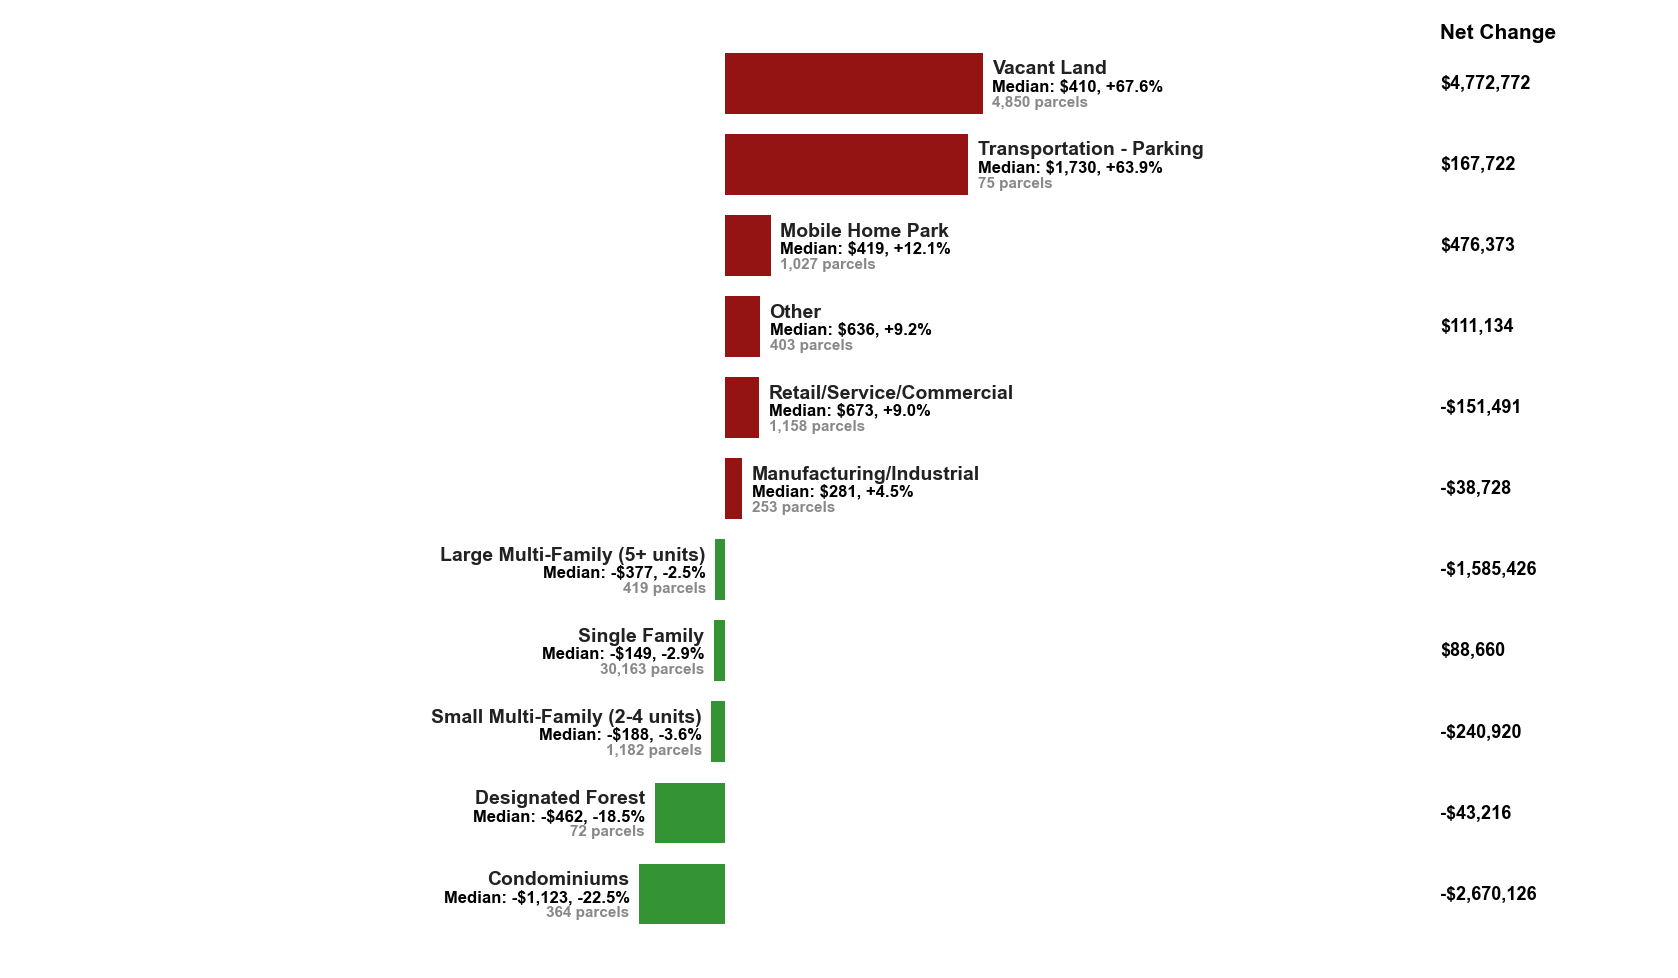

In [1086]:
import matplotlib.pyplot as plt
import numpy as np

# Only include categories with property_count > 50 and exclude "Water Areas" and "Other Residential"
filtered = output_summary[
    (output_summary['property_count'] > 50) &
    (~output_summary['PROPERTY_CATEGORY'].str.contains("Water Areas", case=False, na=False)) &
    (~output_summary['PROPERTY_CATEGORY'].str.contains("Other Residential", case=False, na=False))
].copy()


categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = filtered['total_tax_change'].tolist() if 'total_tax_change' in filtered.columns else (filtered['mean_tax_change'] * filtered['property_count']).tolist()

# Sort by median_pct_change ascending
sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

# Custom color: anything above 0 is dark red, below 0 is green
bar_colors = []
for val in median_pct_change:
    if val > 0:
        bar_colors.append("#8B0000")  # dark red
    else:
        bar_colors.append("#228B22")  # professional green

# Bar settings
bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120  # more padding for right column
fig, ax = plt.subplots(figsize=(17, fig_height))  # wider for right column

y = np.arange(len(categories))

# Draw bars
ax.barh(
    y, median_pct_change, color=bar_colors, edgecolor='none',
    height=bar_height, alpha=0.92, linewidth=0, zorder=2
)

# Remove all spines and ticks for a clean look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Adjusted vertical spacing
cat_offset = 0.18   # less space between category and median
med_offset = -0.03  # median just below category
count_offset = -0.23  # more space below median for parcels

# For right column: position for total tax change
max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

# Add Net Change header at the top of the right column
ax.text(
    right_col_x, len(categories) - 0.5, "Net Change", va='bottom', ha='left',
    fontsize=15, fontweight='bold', color='black', fontname='Arial'
)

for i, (cat, val, count, med_dol, tot_change) in enumerate(zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    # Format median dollar and percent change together
    if med_dol >= 0:
        med_dol_str = f"${med_dol:,.0f}"
    else:
        med_dol_str = f"-${abs(med_dol):,.0f}"
    pct_str = f"{val:+.1f}%"
    median_combo = f"Median: {med_dol_str}, {pct_str}"

    # Position: right of bar for positive, left for negative
    if val < 0:
        xpos = val - 2.5
        ha = 'right'
    else:
        xpos = val + 2.5
        ha = 'left'
    # Category name (bold, bigger)
    ax.text(
        xpos, y[i]+cat_offset, cat, va='center', ha=ha,
        fontsize=14, fontweight='bold', color='#222',
        fontname='Arial'
    )
    # Median (dollar + percent, bold, black, just below category)
    ax.text(
        xpos, y[i]+med_offset, median_combo, va='center', ha=ha,
        fontsize=12, fontweight='bold', color='black',
        fontname='Arial'
    )
    # Count (bold, smaller, below median)
    ax.text(
        xpos, y[i]+count_offset, f"{count:,} parcels", va='center', ha=ha,
        fontsize=11, fontweight='bold', color='#888',
        fontname='Arial'
    )
    # Net change column, always right-aligned in a new column, black text, no "Total:"
    if tot_change >= 0:
        tot_change_str = f"${tot_change:,.0f}"
    else:
        tot_change_str = f"-${abs(tot_change):,.0f}"
    ax.text(
        right_col_x, y[i], tot_change_str, va='center', ha='left',
        fontsize=13, fontweight='bold', color='black',
        fontname='Arial'
    )

# Set x limits for symmetry, make bars longer, and leave space for right column
ax.set_xlim(-right_col_x, right_col_x + 60)

# Remove axis labels/ticks
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()


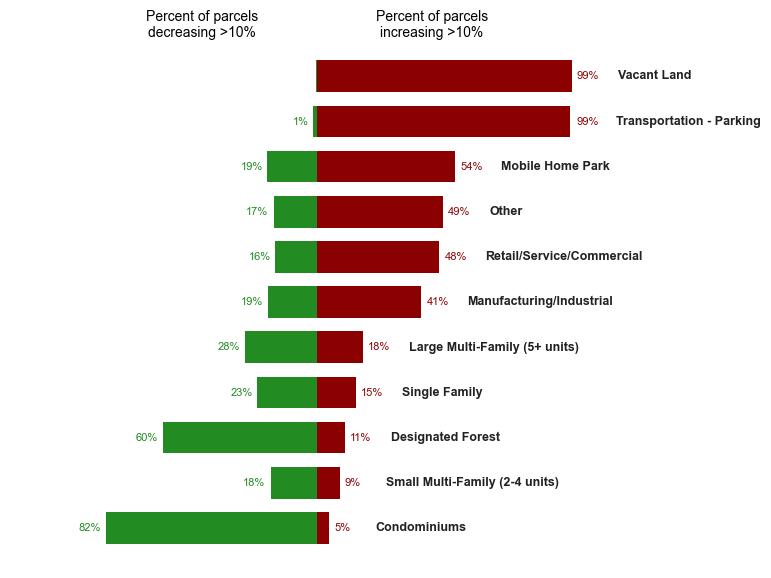

In [1087]:
import matplotlib.pyplot as plt
import numpy as np

# Use output_summary to generate categories and percent increase/decrease, filtering to count > 50 and excluding Water Areas

# Filter to property_count > 50 and exclude "Water Areas"
summary_filtered = output_summary[
    (output_summary['property_count'] > 50) &
    (output_summary['PROPERTY_CATEGORY'].str.lower() != "water areas")&
    (~output_summary['PROPERTY_CATEGORY'].str.contains("Other Residential", case=False, na=False))
].copy()

# Sort by pct_increase_gt_threshold ascending (smallest percent increase first)
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)

categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()

# Convert to integers for display
pct_increase_int_sorted = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int_sorted = [int(round(x)) for x in pct_decrease_sorted]

y = np.arange(len(categories_sorted))

fig, ax = plt.subplots(figsize=(8, 6))

# Use specified colors
color_increase = "#8B0000"  # dark red
color_decrease = "#228B22"  # professional green

# Plot left (decrease) bars (green, to the left)
ax.barh(
    y, 
    [-v for v in pct_decrease_sorted], 
    color=color_decrease, 
    edgecolor='none', 
    height=0.7
)

# Plot right (increase) bars (red, to the right)
ax.barh(
    y, 
    pct_increase_sorted, 
    color=color_increase, 
    edgecolor='none', 
    height=0.7
)

# Add percent labels (integer, no decimals), smaller Arial font
for i, (inc, dec) in enumerate(zip(pct_increase_int_sorted, pct_decrease_int_sorted)):
    # Left side (decrease)
    if dec > 0:
        ax.text(
            -dec - 2, y[i], f"{dec}%", 
            va='center', ha='right', 
            fontsize=8, fontweight='normal', color=color_decrease, fontname='Arial'
        )
    # Right side (increase)
    if inc > 0:
        ax.text(
            inc + 2, y[i], f"{inc}%", 
            va='center', ha='left', 
            fontsize=8, fontweight='normal', color=color_increase, fontname='Arial'
        )

# Add category name at end of right bar, bold, smaller Arial, further from percent
for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(
        xpos, y[i], cat, 
        va='center', ha='left', 
        fontsize=9, fontweight='bold', color='#222', fontname='Arial'
    )

# Remove all spines, ticks, and axis lines for minimalist look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Remove grid, axis, and titles
ax.set_yticks([])
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('')

# Set xlim for symmetry
max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)

# --- Add custom titles above left and right bars ---
# Make the titles a little bit bigger and closer to the center
title_fontsize = 10  # increased from 8
title_color = 'black'
title_fontweight = 'normal'
title_fontname = 'Arial'

# Compute center x for both titles, but offset slightly left/right of center
title_y = len(categories_sorted) - 0.2

# Left title (above left bars), closer to center
left_title_x = -max_val * 0.45
ax.text(
    left_title_x, title_y, 
    "Percent of parcels\ndecreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)

# Right title (above right bars), closer to center
right_title_x = max_val * 0.45
ax.text(
    right_title_x, title_y, 
    "Percent of parcels\nincreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)

plt.tight_layout()
plt.show()


## Step 5: Understanding Property Types and Impacts

With our split-rate tax calculated, we can now analyze which property types are most affected. Understanding the distribution of tax impacts across different property categories is crucial for policy makers and stakeholders.

### Property Type Analysis

We'll examine how the tax burden shifts across:
- **Residential properties** (single-family, multi-family, condos)
- **Commercial properties** (retail, office, industrial)  
- **Vacant land** (often sees largest increases under LVT)
- **Exempt properties** (government, religious, charitable)

### Key Metrics to Track:
- **Count**: Number of properties in each category
- **Median tax change**: Typical impact (less affected by outliers)
- **Average percentage change**: Overall magnitude of impact
- **Percentage with increases**: How many properties see tax increases

This analysis helps identify which sectors benefit from the LVT shift (typically developed properties) and which see increased burden (typically land-intensive properties with low improvement ratios).


### Creating Detailed Property Categories

To better understand impacts, we'll create a detailed property categorization system that groups similar property types together. This makes the analysis more meaningful and interpretable.

The function below categorizes properties into groups like:
- **Single Family** (with subcategories by lot size)
- **Multi-Family** (small vs. large)
- **Commercial** (by type: retail, office, industrial)
- **Exempt** (by type: government, religious, charitable)

This categorization helps us understand not just that "residential" properties are affected, but specifically which types of residential properties see the biggest changes.


In [1088]:
display(df.head())


,OBJECTID,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,millage_AHBH13,millage_BHAH,millage_BHFP,millage_BHGEN,millage_BHGW4,millage_BHGW5,millage_BHRDA,millage_CEM003,millage_CEM004,millage_CEM006,millage_CEM007,millage_CEM010,millage_CFL,millage_FCZDL,millage_FD001EXP,millage_FD004EMS,millage_FD004EXP,millage_FD007BOND,millage_FD007EXP,millage_FD008EXP,millage_FD008MO,millage_FD014EXP,millage_FD017EXP,millage_FD018EXP,millage_FD019EXP,millage_FD021EXP,millage_FD052B,millage_FD052EXP,millage_FERNCE,millage_PTBOND,millage_PTGEN,millage_PTRDA,millage_RDDIV,millage_RDGEN,millage_RLIBGEN,millage_SD501B,millage_SD501CP,millage_SD501MO,millage_SD502B,millage_SD502MO,millage_SD505B,millage_SD505CP,millage_SD505MO,millage_SD506B,millage_SD506MO,millage_SD507CP,millage_SD507MO,millage_WA1,millage_WA2,millage_WCCE,millage_WCCI,millage_WCCT,millage_WCDD,millage_WCEMS,millage_WCER,millage_WCVR,total_millage,exp_flag,exp_amt,current_tax_AHBH13,current_tax_BHAH,current_tax_BHFP,current_tax_BHGEN,current_tax_BHGW4,current_tax_BHGW5,current_tax_BHRDA,current_tax_CEM003,current_tax_CEM004,current_tax_CEM006,current_tax_CEM007,current_tax_CEM010,current_tax_CFL,current_tax_FCZDL,current_tax_FD001EXP,current_tax_FD004EMS,current_tax_FD004EXP,current_tax_FD007BOND,current_tax_FD007EXP,current_tax_FD008EXP,current_tax_FD008MO,current_tax_FD014EXP,current_tax_FD017EXP,current_tax_FD018EXP,current_tax_FD019EXP,current_tax_FD021EXP,current_tax_FD052B,current_tax_FD052EXP,current_tax_FERNCE,current_tax_PTBOND,current_tax_PTGEN,current_tax_PTRDA,current_tax_RDDIV,current_tax_RDGEN,current_tax_RLIBGEN,current_tax_SD501B,current_tax_SD501CP,current_tax_SD501MO,current_tax_SD502B,current_tax_SD502MO,current_tax_SD505B,current_tax_SD505CP,current_tax_SD505MO,current_tax_SD506B,current_tax_SD506MO,current_tax_SD507CP,current_tax_SD507MO,current_tax_WA1,current_tax_WA2,current_tax_WCCE,current_tax_WCCI,current_tax_WCCT,current_tax_WCDD,current_tax_WCEMS,current_tax_WCER,current_tax_WCVR,current_tax,PROPERTY_CATEGORY,new_millage_AHBH13,new_millage_BHAH,new_millage_BHFP,new_millage_BHGEN,new_millage_BHGW4,new_millage_BHGW5,new_millage_BHRDA,new_millage_CEM003,new_millage_CEM004,new_millage_CEM006,new_millage_CEM007,new_millage_CEM010,new_millage_CFL,new_millage_FCZDL,new_millage_FD001EXP,new_millage_FD004EMS,new_millage_FD004EXP,new_millage_FD007BOND,new_millage_FD007EXP,new_millage_FD008EXP,new_millage_FD008MO,new_millage_FD014EXP,new_millage_FD017EXP,new_millage_FD018EXP,new_millage_FD019EXP,new_millage_FD021EXP,new_millage_FD052B,new_millage_FD052EXP,new_millage_FERNCE,new_millage_PTBOND,new_millage_PTGEN,new_millage_PTRDA,new_millage_RDDIV,new_millage_RDGEN,new_millage_RLIBGEN,new_millage_SD501B,new_millage_SD501CP,new_millage_SD501MO,new_millage_SD502B,new_millage_SD502MO,new_millage_SD505B,new_millage_SD505CP,new_millage_SD505MO,new_millage_SD506B,new_millage_SD506MO,new_millage_SD507CP,new_millage_SD507MO,new_millage_WA1,new_millage_WA2,new_millage_WCCE,new_millage_WCCI,new_m

### Summary of Tax Impacts by Property Category

Now we can see the clear patterns of how different property types are affected by the LVT shift. This table will show us:

- **Which property types benefit** (negative changes = tax decreases)
- **Which property types pay more** (positive changes = tax increases)  
- **How concentrated the impacts are** (median vs. average differences)
- **What percentage of each type sees increases**

Generally, we expect:
- **Developed properties** (houses, commercial buildings) to see tax **decreases**
- **Vacant land** to see the **largest increases** 
- **Properties with high improvement-to-land ratios** to benefit most


## Step 6: Adding Geographic Context

To make our analysis spatially-aware, we need to add geographic boundaries to our parcel data. This enables us to:

- **Create maps** showing tax changes across the city
- **Analyze patterns by neighborhood** or district  
- **Combine with demographic data** for equity analysis
- **Present results visually** to stakeholders

We'll fetch the parcel boundary data from the same ArcGIS service that contains the geometric information for each property.


### Merging Tax Analysis with Geographic Data

Here we combine our tax analysis results with the geographic boundaries. This creates a spatially-enabled dataset that allows us to:

1. **Map tax changes** across South Bend
2. **Identify spatial patterns** in tax impacts
3. **Prepare for demographic analysis** by having geographic context

The merge should give us the same number of records as our original analysis, now with geographic coordinates for each parcel.


In [1089]:
# Get census data for Spokane County (FIPS code: 53063)
census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code='53073',  # Washington (53) + Whatcom County (073)
    year=2022
)
# Set CRS for census boundaries before merging
census_boundaries = census_boundaries.set_crs(epsg=4326)  # Assuming WGS84 coordinate system
boundary_gdf = df.set_crs(epsg=4326)  # Set same CRS for boundary data

# Merge census data with our parcel boundaries
df = match_to_census_blockgroups(
    gdf=boundary_gdf,
    census_gdf=census_boundaries,
    join_type="left"
)

print(f"Number of census blocks: {len(census_boundaries)}")
print(f"Number of census data: {len(census_data)}")
print(f"Number of parcels with census data: {len(df)}")

Number of census blocks: 5314
Number of census data: 129
Number of parcels with census data: 41021


## Step 7: Demographic and Equity Analysis

One of the most important aspects of LVT analysis is understanding the **equity implications** - how does the tax shift affect different income levels and demographic groups?

### Adding Census Data

We'll match each property to its Census Block Group and pull demographic data including:
- **Median household income** 
- **Racial/ethnic composition**
- **Population characteristics**

### Why This Matters

Policy makers need to understand:
- Does the LVT shift disproportionately burden low-income neighborhoods?
- Are there racial equity implications?  
- Does the policy align with broader equity goals?

**Note**: You'll need a Census API key for this section. Get one free at: https://api.census.gov/data/key_signup.html


In [1090]:
print("DataFrame columns:")
print(df.columns.tolist())


DataFrame columns:
['OBJECTID_left', 'geo_id', 'prop_id', 'TTRRSSXXXYYY', 'TTRRSS', 'XXXYYY', 'AUX', 'property_type', 'tax_payer_id', 'tax_payer_name', 'tax_payer_line1', 'tax_payer_line2', 'tax_payer_line3', 'tax_payer_city', 'tax_payer_state', 'tax_payer_zip', 'tax_payer_country', 'title_owner_id', 'title_owner_name', 'title_owner_line1', 'title_owner_line2', 'title_owner_line3', 'title_owner_city', 'title_owner_state', 'title_owner_zip', 'title_owner_country', 'situs_num', 'situs_street_prefix', 'situs_street', 'situs_unit', 'situs_city', 'situs_state', 'situs_building_num', 'situs_sub_num', 'zoning', 'zoning_description', 'tax_area_number', 'tax_area_description', 'subdv_cd', 'subdv_description', 'lot', 'block', 'property_use_cd', 'property_use_description', 'lien_type', 'exmpt_type_cd', 'exmpt_subtype_cd', 'legal_description', 'legal_description2', 'long_legal_description', 'legal_acreage', 'market_land_val', 'market_improvement_val', 'market', 'appraised_land_val', 'appraised_imp

### Exploring the Enhanced Dataset

With census data merged in, our dataset now contains both property tax information and demographic context. Let's explore what variables we now have available for analysis.

This enhanced dataset allows us to examine relationships between:
- Property characteristics and demographics
- Tax impacts and neighborhood income levels
- Geographic patterns in tax burden shifts


In [1091]:
# Display all columns with maximum width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df.head())


,OBJECTID_left,geo_id,prop_id,TTRRSSXXXYYY,TTRRSS,XXXYYY,AUX,property_type,tax_payer_id,tax_payer_name,tax_payer_line1,tax_payer_line2,tax_payer_line3,tax_payer_city,tax_payer_state,tax_payer_zip,tax_payer_country,title_owner_id,title_owner_name,title_owner_line1,title_owner_line2,title_owner_line3,title_owner_city,title_owner_state,title_owner_zip,title_owner_country,situs_num,situs_street_prefix,situs_street,situs_unit,situs_city,situs_state,situs_building_num,situs_sub_num,zoning,zoning_description,tax_area_number,tax_area_description,subdv_cd,subdv_description,lot,block,property_use_cd,property_use_description,lien_type,exmpt_type_cd,exmpt_subtype_cd,legal_description,legal_description2,long_legal_description,legal_acreage,market_land_val,market_improvement_val,market,appraised_land_val,appraised_improvement_val,appraised_val_total,senior_value,taxable_val_total,Hyperlink,tax_payer_name_full,tax_payer_add_full,title_owner_name_full,title_owner_add_full,imprv_type,yr_blt,sqft_la,BUFF_DIST,ORIG_FID,Shape.STArea(),Shape.STLength(),geometry,millage_AHBH13,millage_BHAH,millage_BHFP,millage_BHGEN,millage_BHGW4,millage_BHGW5,millage_BHRDA,millage_CEM003,millage_CEM004,millage_CEM006,millage_CEM007,millage_CEM010,millage_CFL,millage_FCZDL,millage_FD001EXP,millage_FD004EMS,millage_FD004EXP,millage_FD007BOND,millage_FD007EXP,millage_FD008EXP,millage_FD008MO,millage_FD014EXP,millage_FD017EXP,millage_FD018EXP,millage_FD019EXP,millage_FD021EXP,millage_FD052B,millage_FD052EXP,millage_FERNCE,millage_PTBOND,millage_PTGEN,millage_PTRDA,millage_RDDIV,millage_RDGEN,millage_RLIBGEN,millage_SD501B,millage_SD501CP,millage_SD501MO,millage_SD502B,millage_SD502MO,millage_SD505B,millage_SD505CP,millage_SD505MO,millage_SD506B,millage_SD506MO,millage_SD507CP,millage_SD507MO,millage_WA1,millage_WA2,millage_WCCE,millage_WCCI,millage_WCCT,millage_WCDD,millage_WCEMS,millage_WCER,millage_WCVR,total_millage,exp_flag,exp_amt,current_tax_AHBH13,current_tax_BHAH,current_tax_BHFP,current_tax_BHGEN,current_tax_BHGW4,current_tax_BHGW5,current_tax_BHRDA,current_tax_CEM003,current_tax_CEM004,current_tax_CEM006,current_tax_CEM007,current_tax_CEM010,current_tax_CFL,current_tax_FCZDL,current_tax_FD001EXP,current_tax_FD004EMS,current_tax_FD004EXP,current_tax_FD007BOND,current_tax_FD007EXP,current_tax_FD008EXP,current_tax_FD008MO,current_tax_FD014EXP,current_tax_FD017EXP,current_tax_FD018EXP,current_tax_FD019EXP,current_tax_FD021EXP,current_tax_FD052B,current_tax_FD052EXP,current_tax_FERNCE,current_tax_PTBOND,current_tax_PTGEN,current_tax_PTRDA,current_tax_RDDIV,current_tax_RDGEN,current_tax_RLIBGEN,current_tax_SD501B,current_tax_SD501CP,current_tax_SD501MO,current_tax_SD502B,current_tax_SD502MO,current_tax_SD505B,current_tax_SD505CP,current_tax_SD505MO,current_tax_SD506B,current_tax_SD506MO,current_tax_SD507CP,current_tax_SD507MO,current_tax_WA1,current_tax_WA2,current_tax_WCCE,current_tax_WCCI,current_tax_WCCT,current_tax_WCDD,current_tax_WCEMS,current_tax_WCER,current_tax_WCVR,current_tax,PROPERTY_CATEGORY,new_millage_AHBH13,new_millage_BHAH,new_millage_BHFP,new_millage_BHGEN,new_millage_BHGW4,new_millage_BHGW5,new_millage_BHRDA,new_millage_CEM003,new_millage_CEM004,new_millage_CEM006,new_millage_CEM007,new_millage_CEM010,new_millage_CFL,new_millage_FCZDL,new_millage_FD001EXP,new_millage_FD004EMS,new_millage_FD004EXP,new_millage_FD007BOND,new_millage_FD007EXP,new_millage_FD008EXP,new_millage_FD008MO,new_millage_FD014EXP,new_millage_FD017EXP,new_millage_FD018EXP,new_millage_FD019EXP,new_millage_FD021EXP,new_millage_FD052B,new_millage_FD052EXP,new_millage_FERNCE,new_millage_PTBOND,new_millage_PTGEN,new_millage_PTRDA,new_millage_RDDIV,new_millage_RDGEN,new_millage_RLIBGEN,new_millage_SD501B,new_millage_SD501CP,new_millage_SD501MO,new_millage_SD502B,new_millage_SD502MO,new_millage_SD505B,new_millage_SD505CP,new_millage_SD505MO,new_millage_SD506B,new_millage_SD506MO,new_millage_SD507CP,new_millage_SD507MO,new_millage_WA1,new_millage_WA2,new_millage_WCCE,new_millage_WCCI,

### Viewing the Complete Dataset

Let's examine our enhanced dataset with all the variables we've created and merged. This gives us a comprehensive view of each property with:

- **Property characteristics** (type, value, location)
- **Current tax calculations** 
- **New LVT calculations**
- **Tax change impacts**
- **Demographic context** (income, race/ethnicity)

This rich dataset forms the foundation for sophisticated equity and impact analysis.


Number of rows in gdf_filtered: 40511
Number of rows in non_vacant_gdf: 35737


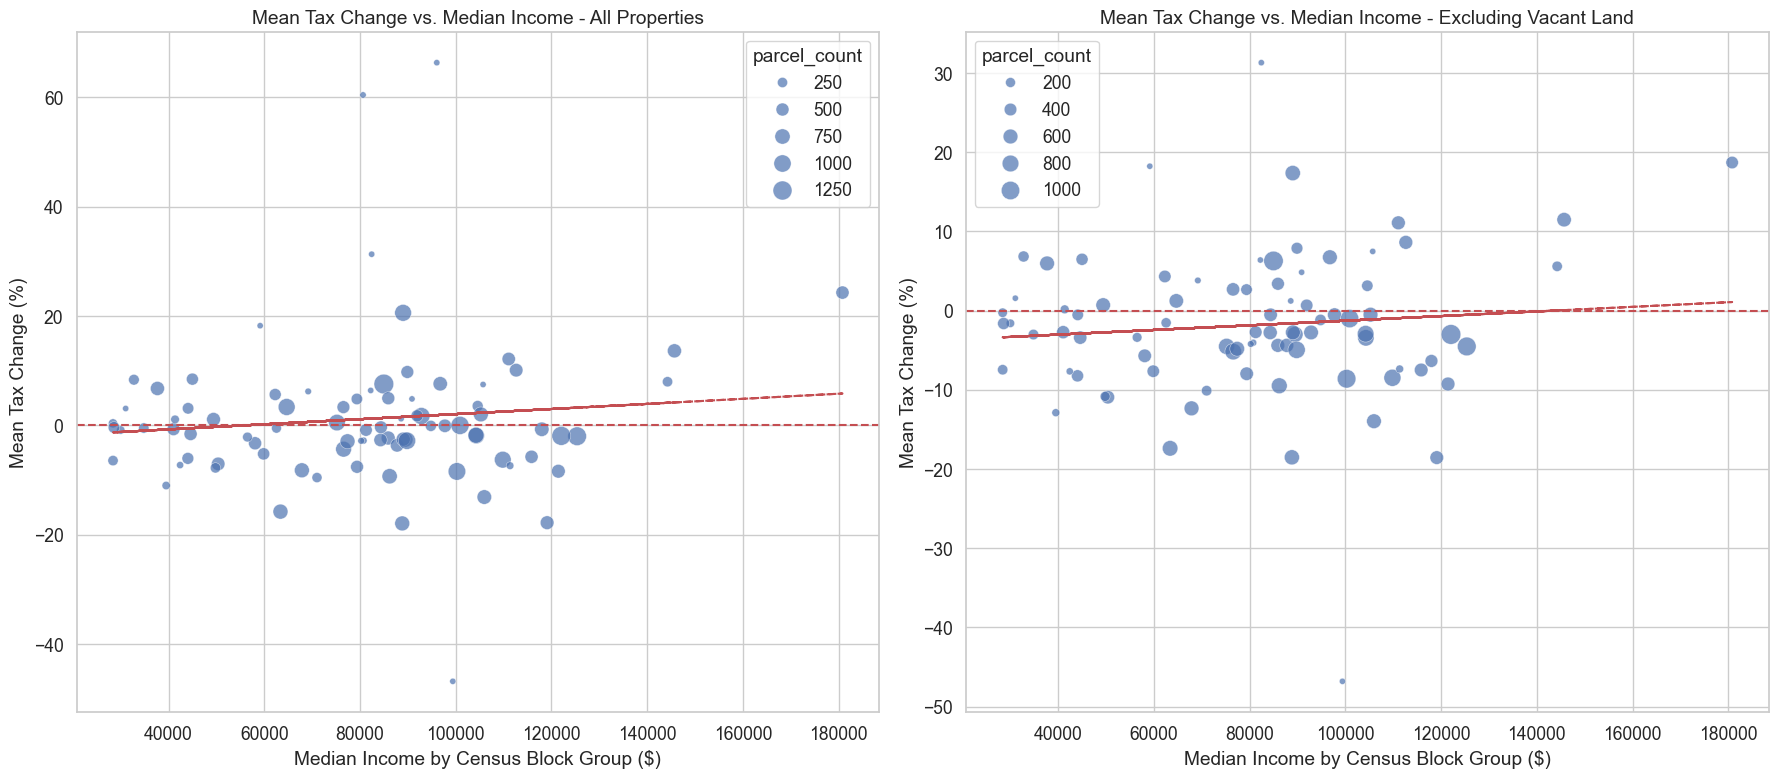

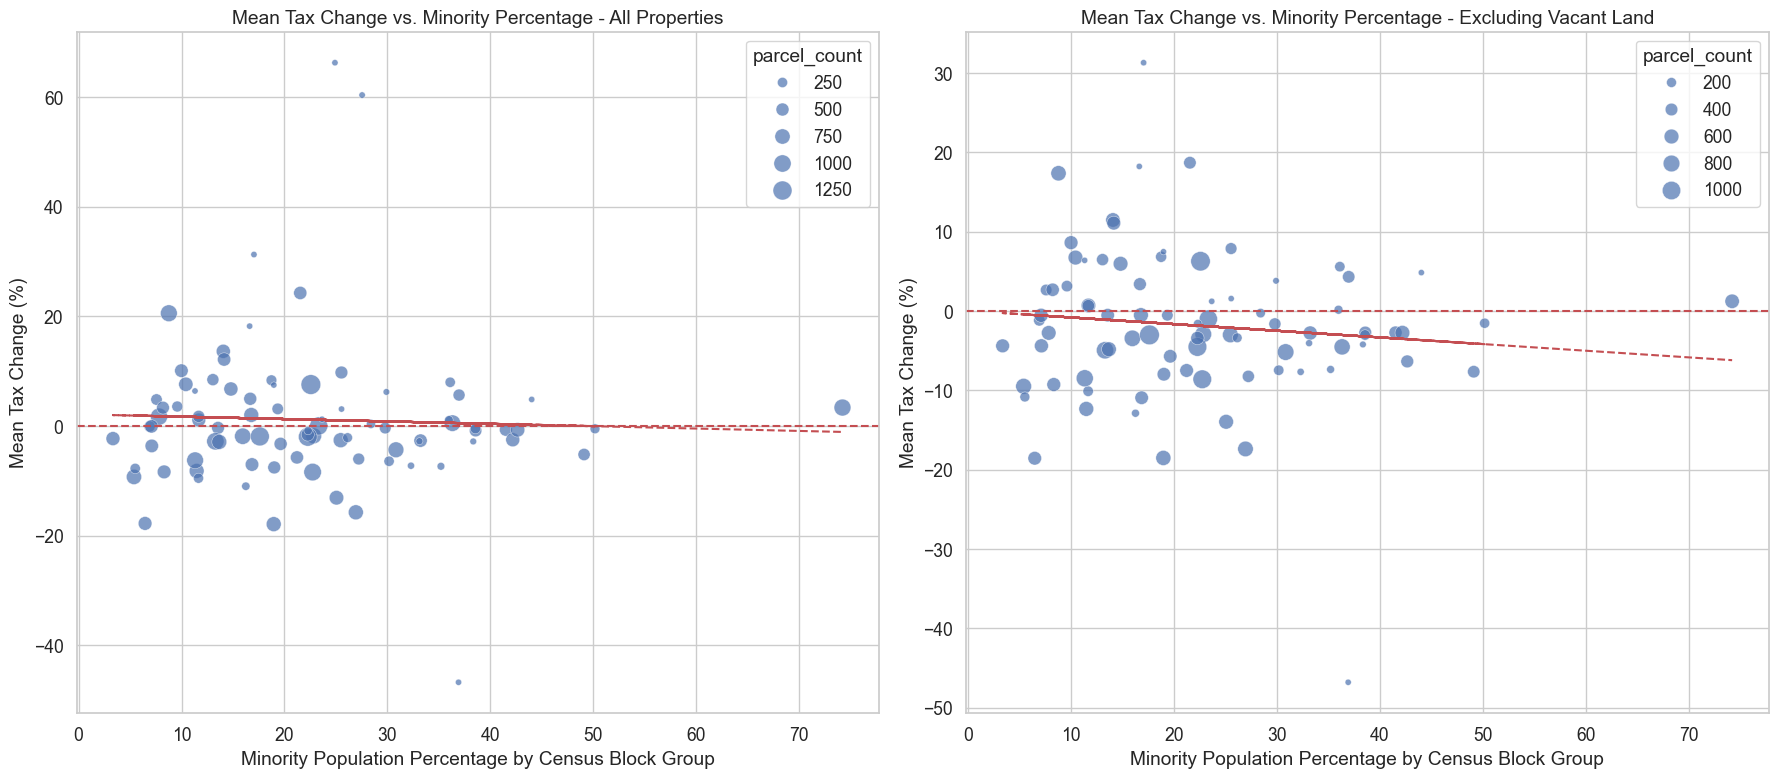

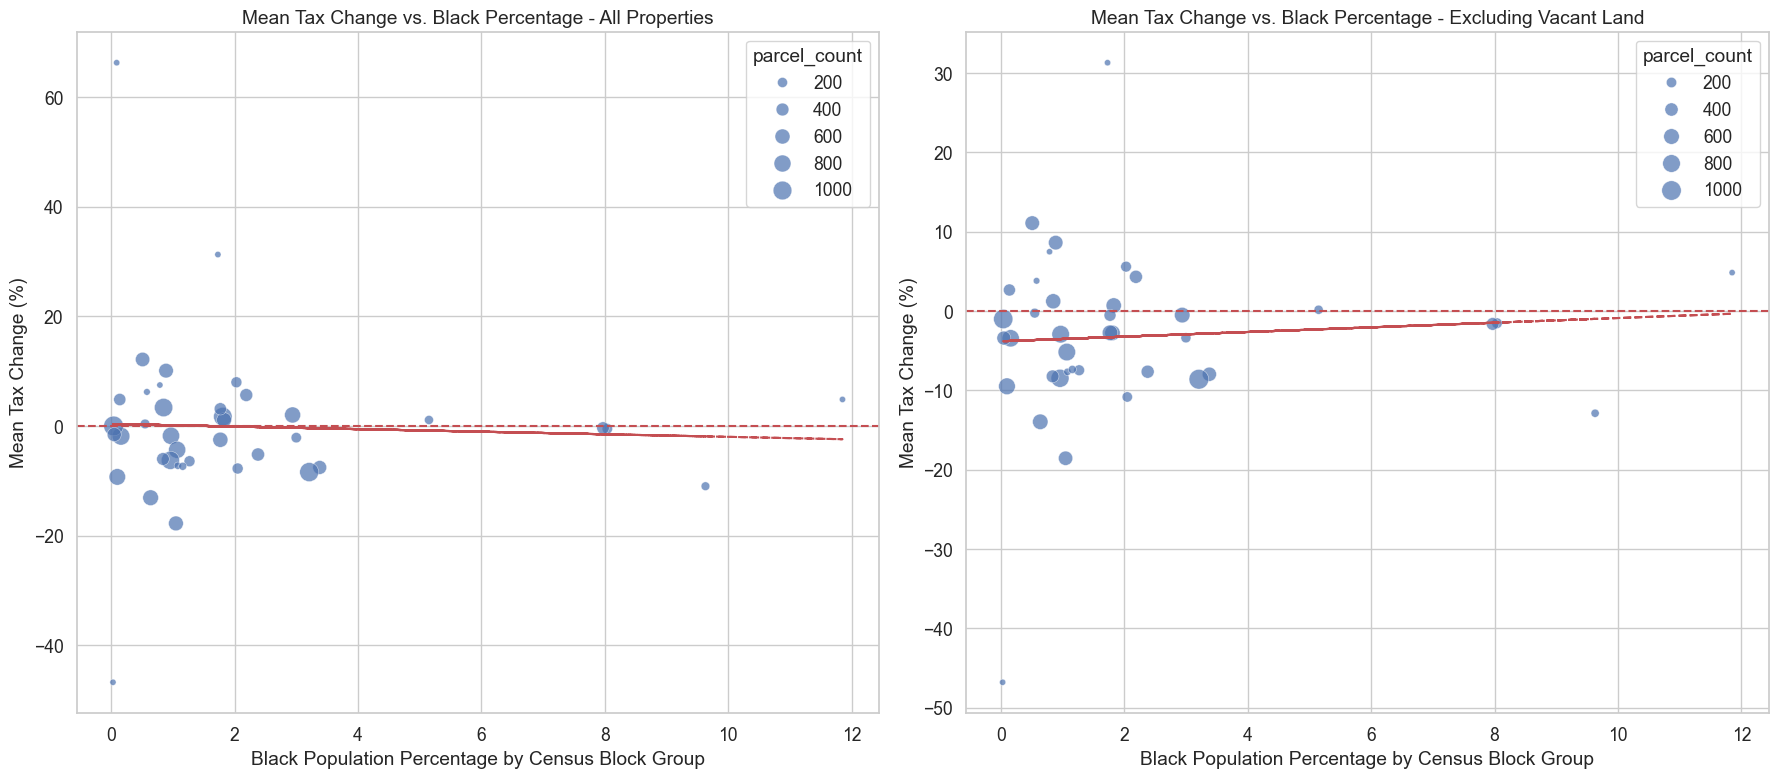

Correlation income_mean_all: 0.1021
Correlation income_median_all: -0.0910
Correlation minority_mean_all: -0.0400
Correlation black_mean_all: -0.0729
Correlation income_mean_non_vacant: 0.0917
Correlation income_median_non_vacant: -0.0341
Correlation minority_mean_non_vacant: -0.1109
Correlation black_mean_non_vacant: -0.0180


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: The default of observed=False is deprecated and will 


Tax impact by income quintile (all properties):


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping colum

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),8443.0,-0.662741,-0.470563,46944.197086
1,Q2,8546.0,4.139009,-1.156388,77062.447227
2,Q3,8235.0,4.159121,-0.855164,89025.056102
3,Q4,7985.0,-0.984559,-2.991836,102728.642329
4,Q5 (Highest),7302.0,3.847618,1.453242,126849.439058


...

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),7742.0,-6.799441,-1.717366,46930.859339
1,Q2,7393.0,-5.685118,-3.078754,77616.258082
2,Q3,6316.0,-7.977867,-3.550674,88501.381571
3,Q4,7909.0,-6.948550,-3.993948,101926.436971
4,Q5 (Highest),6377.0,-5.250577,-1.332804,126299.384036



Tax impact by minority percentage quintile (all properties):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),8418.0,4.714231,2.517191,7.546435
1,Q2,8129.0,4.215769,0.408459,13.212637
2,Q3,8196.0,1.571280,-2.362952,19.301057
3,Q4,7823.0,-2.265257,-4.003100,24.250175
4,Q5 (Highest),7945.0,1.906725,-0.851950,42.133366



Tax impact by minority percentage quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),7163.0,-5.962307,-0.525219,7.539886
1,Q2,7355.0,-2.380897,-1.015321,13.202280
2,Q3,7293.0,-6.469591,-4.059841,19.291000
3,Q4,6900.0,-10.165808,-5.589882,24.149030
4,Q5 (Highest),7026.0,-7.963602,-2.701303,40.271322


In [1092]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def filter_data(df):
    """Filter data to remove negative or zero median incomes and create non-vacant subset (also with positive income)"""
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def calculate_block_group_summary(df):
    """Calculate summary statistics for census block groups, excluding negative/zero median incomes"""
    # Only include block groups with positive median income
    df = df[df['median_income'] > 0].copy()
    summary = df.groupby('std_geoid').agg(
        median_income=('median_income', 'first'),
        minority_pct=('minority_pct', 'first'),
        black_pct=('black_pct', 'first'),
        total_current_tax=('current_tax', 'sum'),
        total_new_tax=('new_tax', 'sum'),
        mean_tax_change=('tax_change', 'mean'),
        median_tax_change=('tax_change', 'median'),
        median_tax_change_pct=('tax_change_pct', 'median'),
        parcel_count=('tax_change', 'count'),
        has_vacant_land=('PROPERTY_CATEGORY', lambda x: 'Vacant Land' in x.values)
    ).reset_index()
    # Exclude block groups with non-positive median income (shouldn't be needed, but for safety)
    summary = summary[summary['median_income'] > 0].copy()
    summary['mean_tax_change_pct'] = ((summary['total_new_tax'] - summary['total_current_tax']) / 
                                    summary['total_current_tax']) * 100
    return summary

def create_scatter_plot(data, x_col, y_col, ax, title, xlabel, ylabel):
    """Create a scatter plot with trend line, excluding negative/zero incomes"""
    # Exclude rows with non-positive x_col (e.g., median_income)
    data = data[data[x_col] > 0].copy()
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        size='parcel_count',
        sizes=(20, 200),
        alpha=0.7,
        ax=ax
    )
    
    ax.axhline(y=0, color='r', linestyle='--')
    
    x = data[x_col].dropna()
    y = data[y_col].dropna()
    mask = ~np.isnan(x) & ~np.isnan(y)
    
    if len(x[mask]) > 1:
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        ax.plot(x[mask], p(x[mask]), "r--")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

def plot_comparison(data1, data2, x_col, y_col, title_prefix, xlabel):
    """Create side-by-side comparison plots, excluding negative/zero incomes"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    create_scatter_plot(data1, x_col, y_col, ax1, 
                       f'{title_prefix} - All Properties', xlabel, 'Mean Tax Change (%)')
    create_scatter_plot(data2, x_col, y_col, ax2,
                       f'{title_prefix} - Excluding Vacant Land', xlabel, 'Mean Tax Change (%)')
    
    plt.tight_layout()
    plt.show()

def calculate_correlations(data1, data2):
    """Calculate correlations between variables, excluding negative/zero incomes"""
    correlations = {}
    for df, suffix in [(data1, 'all'), (data2, 'non_vacant')]:
        # Exclude rows with non-positive median_income for correlation
        df_corr = df[df['median_income'] > 0].copy()
        correlations[f'income_mean_{suffix}'] = df_corr[['median_income', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'income_median_{suffix}'] = df_corr[['median_income', 'median_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'minority_mean_{suffix}'] = df_corr[['minority_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'black_mean_{suffix}'] = df_corr[['black_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
    return correlations

def weighted_median(values, weights):
    """Compute the weighted median of values with corresponding weights."""
    # Remove NaNs
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = np.array(values)[mask]
    weights = np.array(weights)[mask]
    if len(values) == 0:
        return np.nan
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumsum = np.cumsum(weights)
    cutoff = weights.sum() / 2.0
    return values[np.searchsorted(cumsum, cutoff)]

def create_quintile_summary(df, group_col, value_col):
    """Create summary statistics by quintiles, using mean/weighted-median tax change percent, excluding negative/zero incomes for income-based quintiles"""
    # If grouping by income, exclude non-positive values
    if group_col == 'median_income':
        df = df[df['median_income'] > 0].copy()
    df[f'{group_col}_quintile'] = pd.qcut(df[group_col], 5, 
                                         labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"])
    
    def weighted_median_tax_change_pct(subdf):
        # Use parcel_count as weights if available, else weight each row equally
        if 'parcel_count' in subdf.columns:
            weights = subdf['parcel_count']
        else:
            weights = np.ones(len(subdf))
        return weighted_median(subdf['tax_change_pct'], weights)
    
    # For this context, each row is a parcel, so weight by 1 (or by parcel_count if already aggregated)
    summary = df.groupby(f'{group_col}_quintile').apply(
        lambda g: pd.Series({
            'count': g['tax_change'].count(),
            'mean_tax_change_pct': g['tax_change_pct'].mean(),
            'median_tax_change_pct': weighted_median(g['tax_change_pct'], np.ones(len(g))),
            'mean_value': g[value_col].mean()
        })
    ).reset_index()
    
    return summary

# Main execution
gdf_filtered, non_vacant_gdf = filter_data(df)
print(f"Number of rows in gdf_filtered: {len(gdf_filtered)}")
print(f"Number of rows in non_vacant_gdf: {len(non_vacant_gdf)}")

# Calculate block group summaries (all with positive median_income only)
census_block_groups = calculate_block_group_summary(gdf_filtered)
non_vacant_block_summary = calculate_block_group_summary(non_vacant_gdf)

# Create comparison plots (all with positive median_income only)
plot_comparison(census_block_groups, non_vacant_block_summary, 
               'median_income', 'mean_tax_change_pct', 
               'Mean Tax Change vs. Median Income', 
               'Median Income by Census Block Group ($)')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'minority_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Minority Percentage',
               'Minority Population Percentage by Census Block Group')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'black_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Black Percentage',
               'Black Population Percentage by Census Block Group')

# Calculate and print correlations (all with positive median_income only)
correlations = calculate_correlations(census_block_groups, non_vacant_block_summary)
for key, value in correlations.items():
    print(f"Correlation {key}: {value:.4f}")

# Create and display quintile summaries (income quintiles exclude negative/zero incomes)
income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print("\nTax impact by income quintile (all properties):")
display(income_quintile_summary)
print("\nTax impact by income quintile (excluding vacant land):")
display(non_vacant_income_quintile_summary)
print("\nTax impact by minority percentage quintile (all properties):")
display(minority_quintile_summary)
print("\nTax impact by minority percentage quintile (excluding vacant land):")
display(non_vacant_minority_quintile_summary)


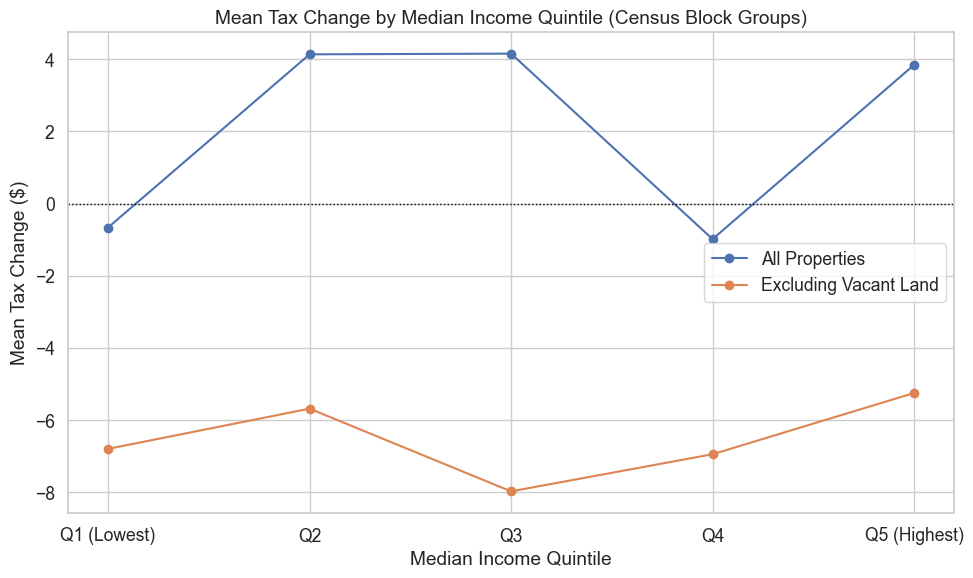

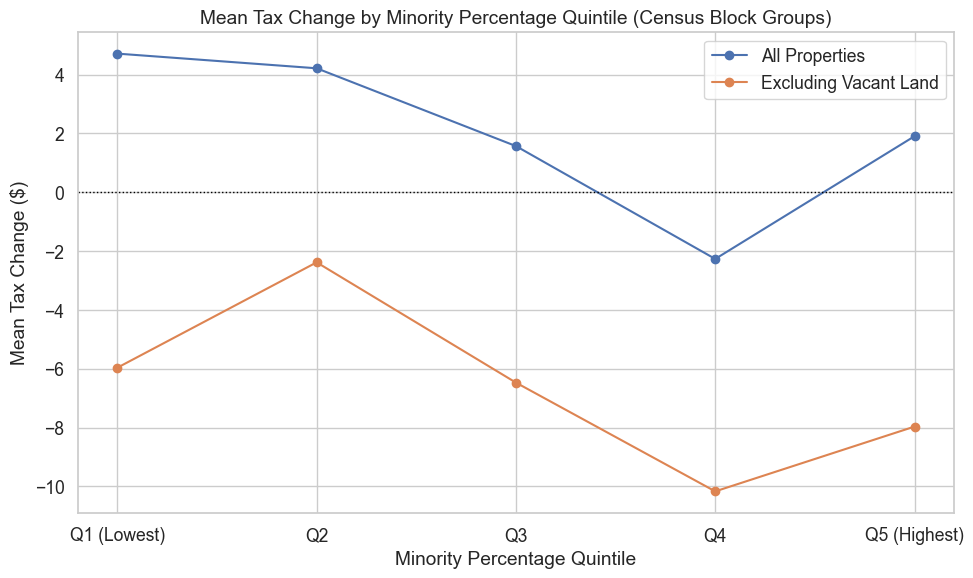

In [1093]:
# Plot 1: Median Income Quintiles vs. Mean Tax Change Percent (Census Block Groups)

plt.figure(figsize=(10, 6))
plt.plot(
    income_quintile_summary['median_income_quintile'],
    income_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='All Properties'
)
plt.plot(
    non_vacant_income_quintile_summary['median_income_quintile'],
    non_vacant_income_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Median Income Quintile')
plt.ylabel('Mean Tax Change ($)')
plt.title('Mean Tax Change by Median Income Quintile (Census Block Groups)')
plt.legend()
# Remove grid
# Ensure x-axis at y=0 if negative values present
ymin = min(
    income_quintile_summary['mean_tax_change_pct'].min(),
    non_vacant_income_quintile_summary['mean_tax_change_pct'].min()
)
ymax = max(
    income_quintile_summary['mean_tax_change_pct'].max(),
    non_vacant_income_quintile_summary['mean_tax_change_pct'].max()
)
if ymin < 0 < ymax:
    plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

# Plot 2: Minority Percentage Quintiles vs. Mean Tax Change Percent (Census Block Groups)

plt.figure(figsize=(10, 6))
plt.plot(
    minority_quintile_summary['minority_pct_quintile'],
    minority_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='All Properties'
)
plt.plot(
    non_vacant_minority_quintile_summary['minority_pct_quintile'],
    non_vacant_minority_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Mean Tax Change ($)')
plt.title('Mean Tax Change by Minority Percentage Quintile (Census Block Groups)')
plt.legend()
# Remove grid
# Ensure x-axis at y=0 if negative values present
ymin2 = min(
    minority_quintile_summary['mean_tax_change_pct'].min(),
    non_vacant_minority_quintile_summary['mean_tax_change_pct'].min()
)
ymax2 = max(
    minority_quintile_summary['mean_tax_change_pct'].max(),
    non_vacant_minority_quintile_summary['mean_tax_change_pct'].max()
)
if ymin2 < 0 < ymax2:
    plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()


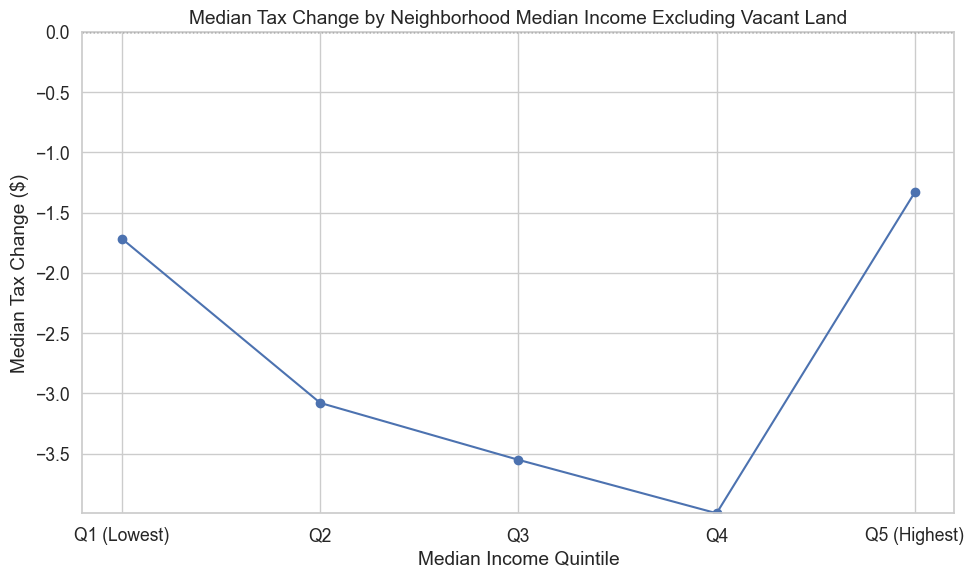

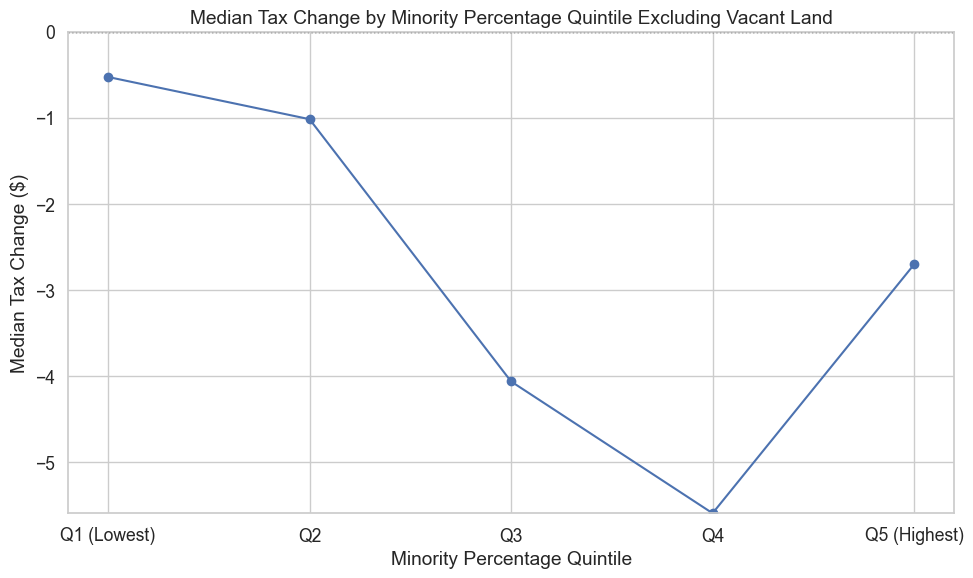

In [1094]:
# Plot: Median Tax Change by Neighborhood Median Income Excluding Vacant Land

plt.figure(figsize=(10, 6))
plt.plot(
    non_vacant_income_quintile_summary['median_income_quintile'],
    non_vacant_income_quintile_summary['median_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Median Income Quintile')
plt.ylabel('Median Tax Change ($)')
plt.title('Median Tax Change by Neighborhood Median Income Excluding Vacant Land')
ymin = non_vacant_income_quintile_summary['median_tax_change_pct'].min()
ymax = non_vacant_income_quintile_summary['median_tax_change_pct'].max()
# Ensure 0 is included on the y-axis
plt.ylim(min(ymin, 0), max(ymax, 0) if ymax < 0 else max(ymax, 0, 1.05*ymax))
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

# Plot: Median Tax Change by Minority Percentage Quintile Excluding Vacant Land

plt.figure(figsize=(10, 6))
plt.plot(
    non_vacant_minority_quintile_summary['minority_pct_quintile'],
    non_vacant_minority_quintile_summary['median_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Median Tax Change ($)')
plt.title('Median Tax Change by Minority Percentage Quintile Excluding Vacant Land')
ymin2 = non_vacant_minority_quintile_summary['median_tax_change_pct'].min()
ymax2 = non_vacant_minority_quintile_summary['median_tax_change_pct'].max()
# Ensure 0 is included on the y-axis
plt.ylim(min(ymin2, 0), max(ymax2, 0) if ymax2 < 0 else max(ymax2, 0, 1.05*ymax2))
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()


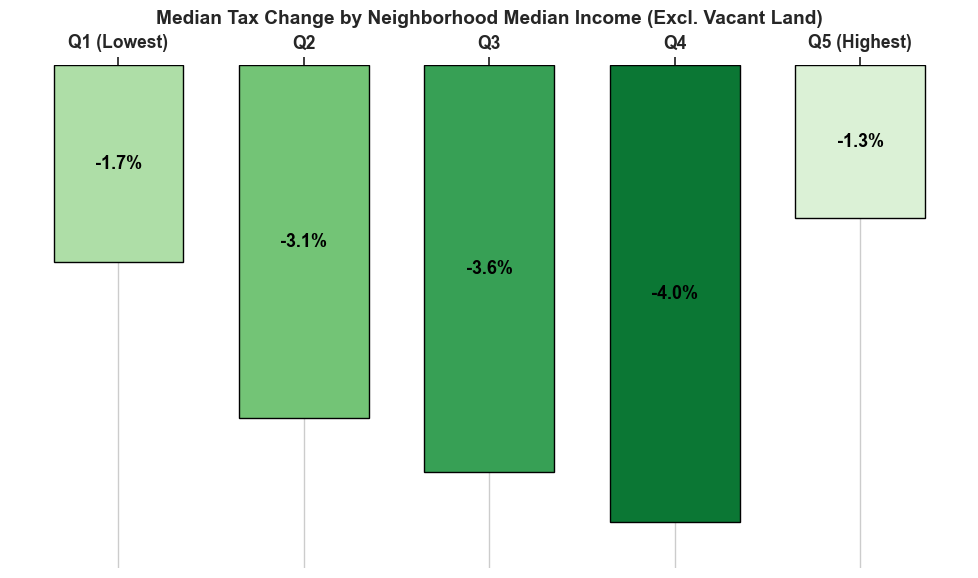

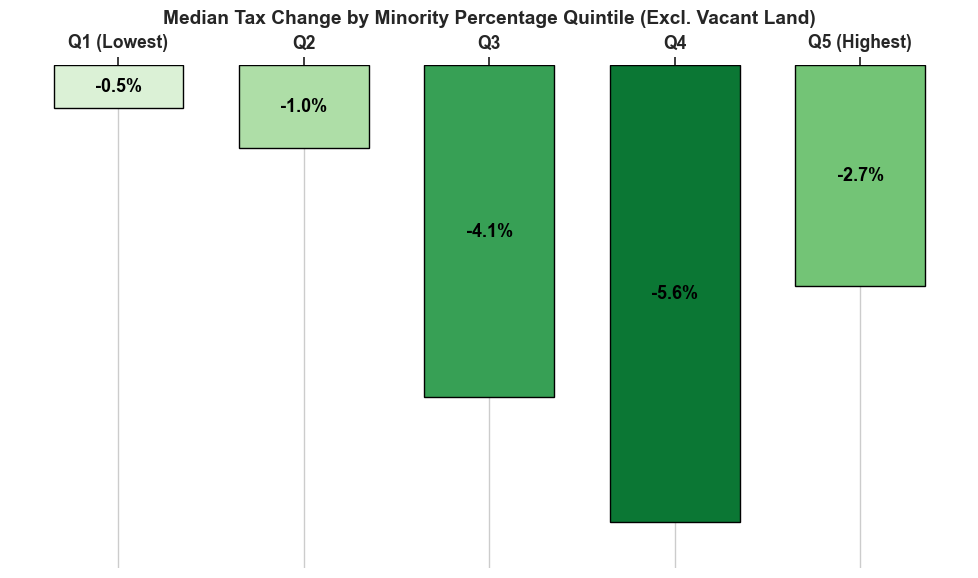

In [1095]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a modern style
sns.set_theme(style="whitegrid", font_scale=1.15)

# Upside Down Bar Graph: Median Tax Change by Neighborhood Median Income Excluding Vacant Land
fig, ax = plt.subplots(figsize=(10, 6))

vals = non_vacant_income_quintile_summary['median_tax_change_pct']
labels = non_vacant_income_quintile_summary['median_income_quintile']

# Color mapping: dark green (more negative) to light green (less negative)
colors = sns.color_palette("Greens", n_colors=len(vals))
# Sort so that the most negative (largest magnitude) is darkest
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

# To make bars start at the top and go down, invert the y-axis and plot positive heights
bars = ax.bar(
    labels,
    np.abs(vals),
    color=color_map,
    edgecolor='black',
    width=0.7
)

# Invert the y-axis so bars start at the top and go down
ax.invert_yaxis()

# Remove y-axis
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)', weight='bold', pad=30)

# Remove all spines (including bottom)
sns.despine(left=True, right=True, top=True, bottom=True)

# Add value labels (bold, % sign) centered inside each bar (no line below the bar)
for bar, val in zip(bars, vals):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

# Move x-tick labels to the top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

# Set y-limits to show bars going down from the top
ymax = np.abs(vals).max() * 1.1
ax.set_ylim(ymax, 0)

plt.tight_layout()
plt.show()

# Upside Down Bar Graph: Median Tax Change by Minority Percentage Quintile Excluding Vacant Land
fig, ax = plt.subplots(figsize=(10, 6))

vals2 = non_vacant_minority_quintile_summary['median_tax_change_pct']
labels2 = non_vacant_minority_quintile_summary['minority_pct_quintile']

colors2 = sns.color_palette("Greens", n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]

bars2 = ax.bar(
    labels2,
    np.abs(vals2),
    color=color_map2,
    edgecolor='black',
    width=0.7
)

ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)

for bar, val in zip(bars2, vals2):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

ymax2 = np.abs(vals2).max() * 1.1
ax.set_ylim(ymax2, 0)

plt.tight_layout()
plt.show()


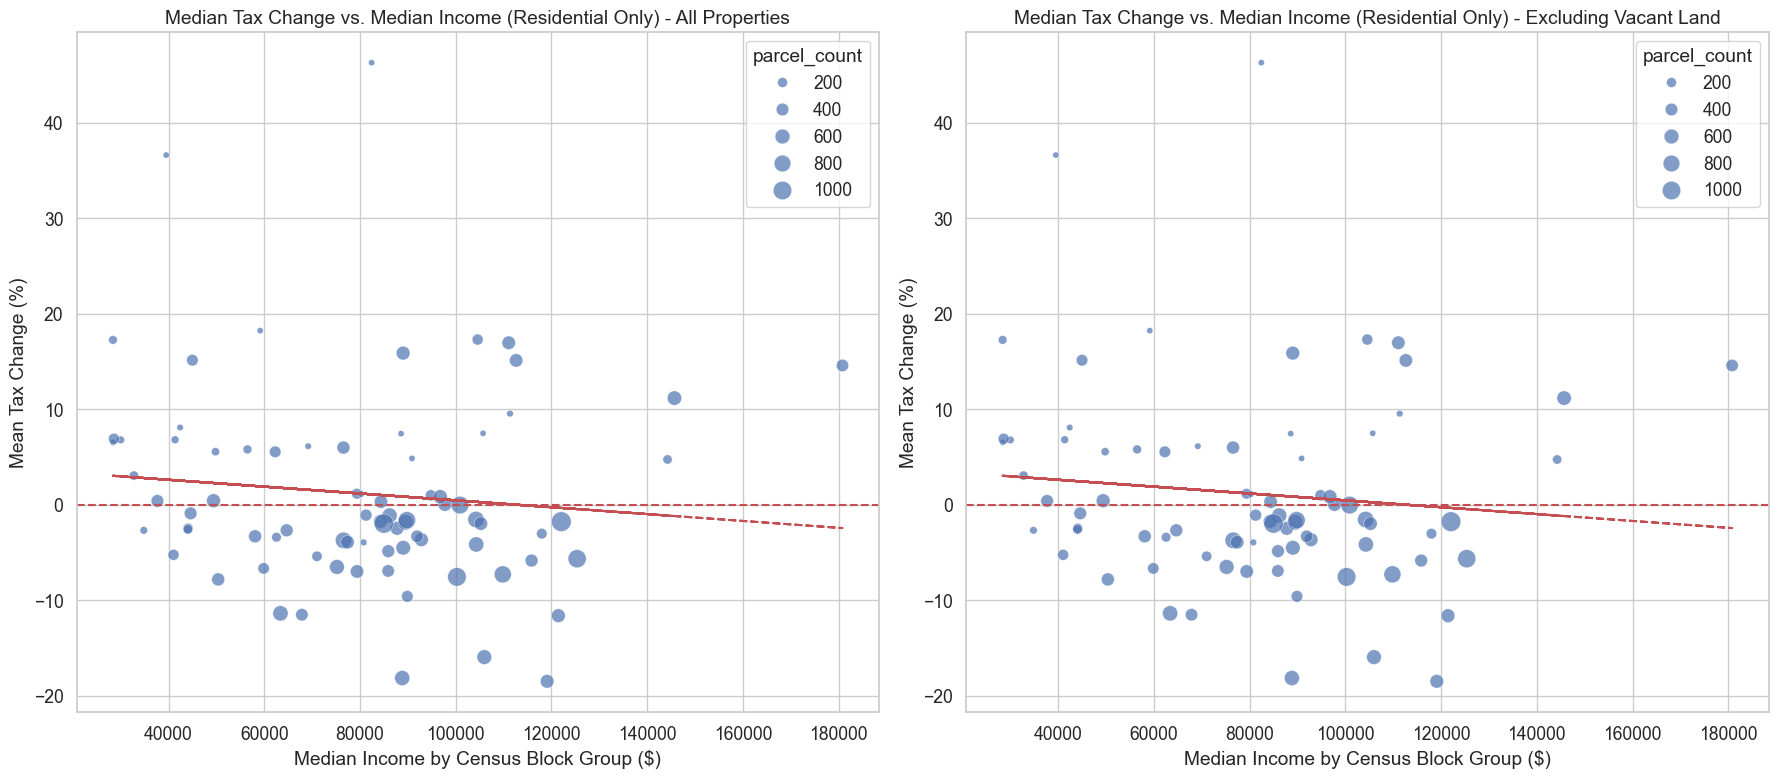

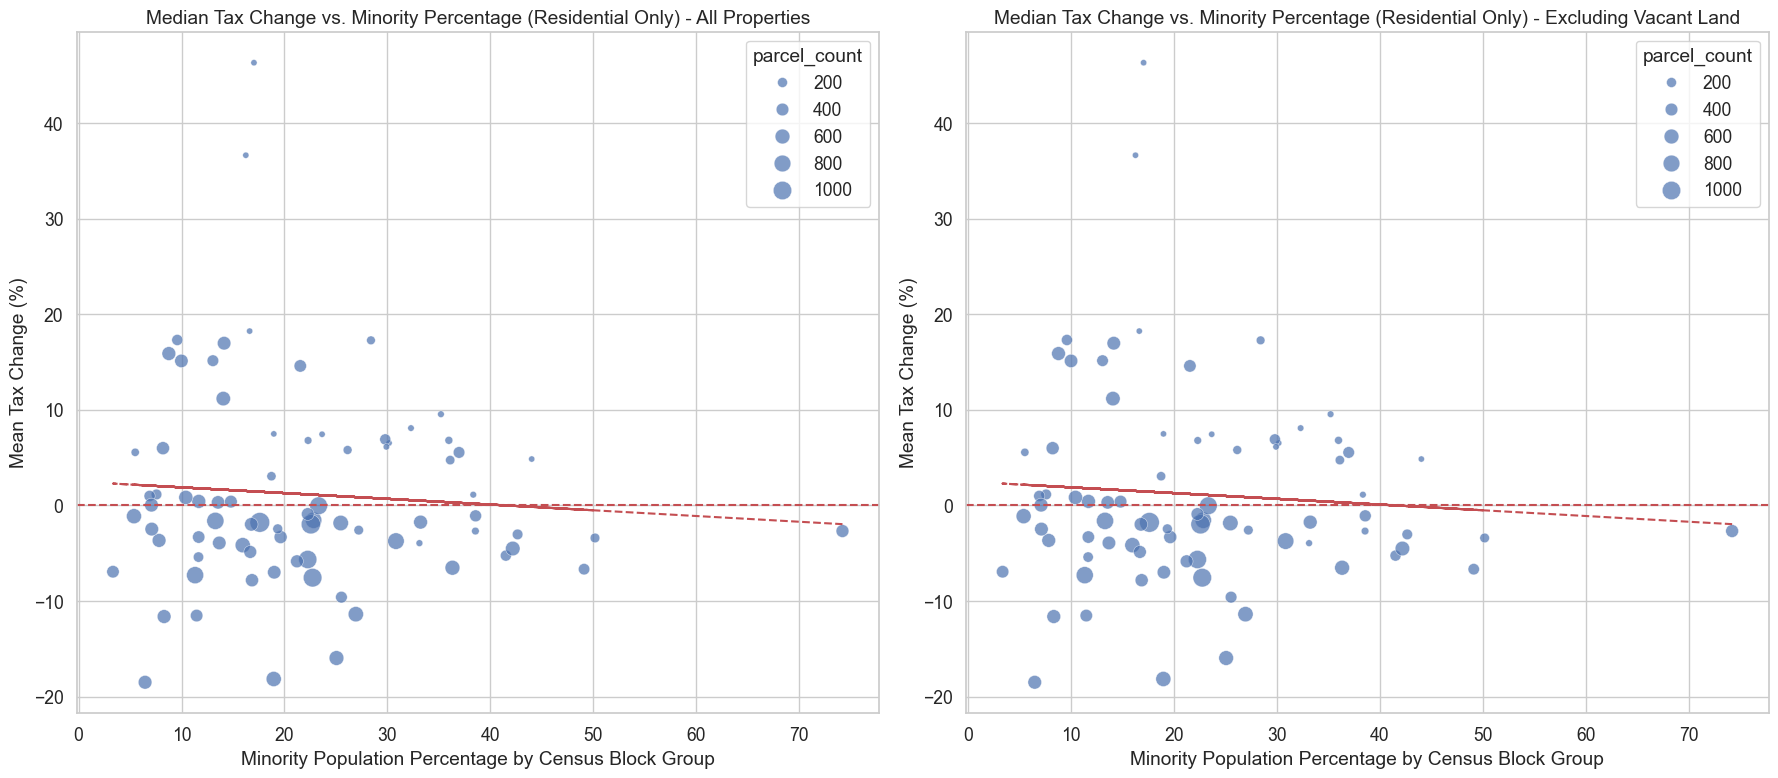

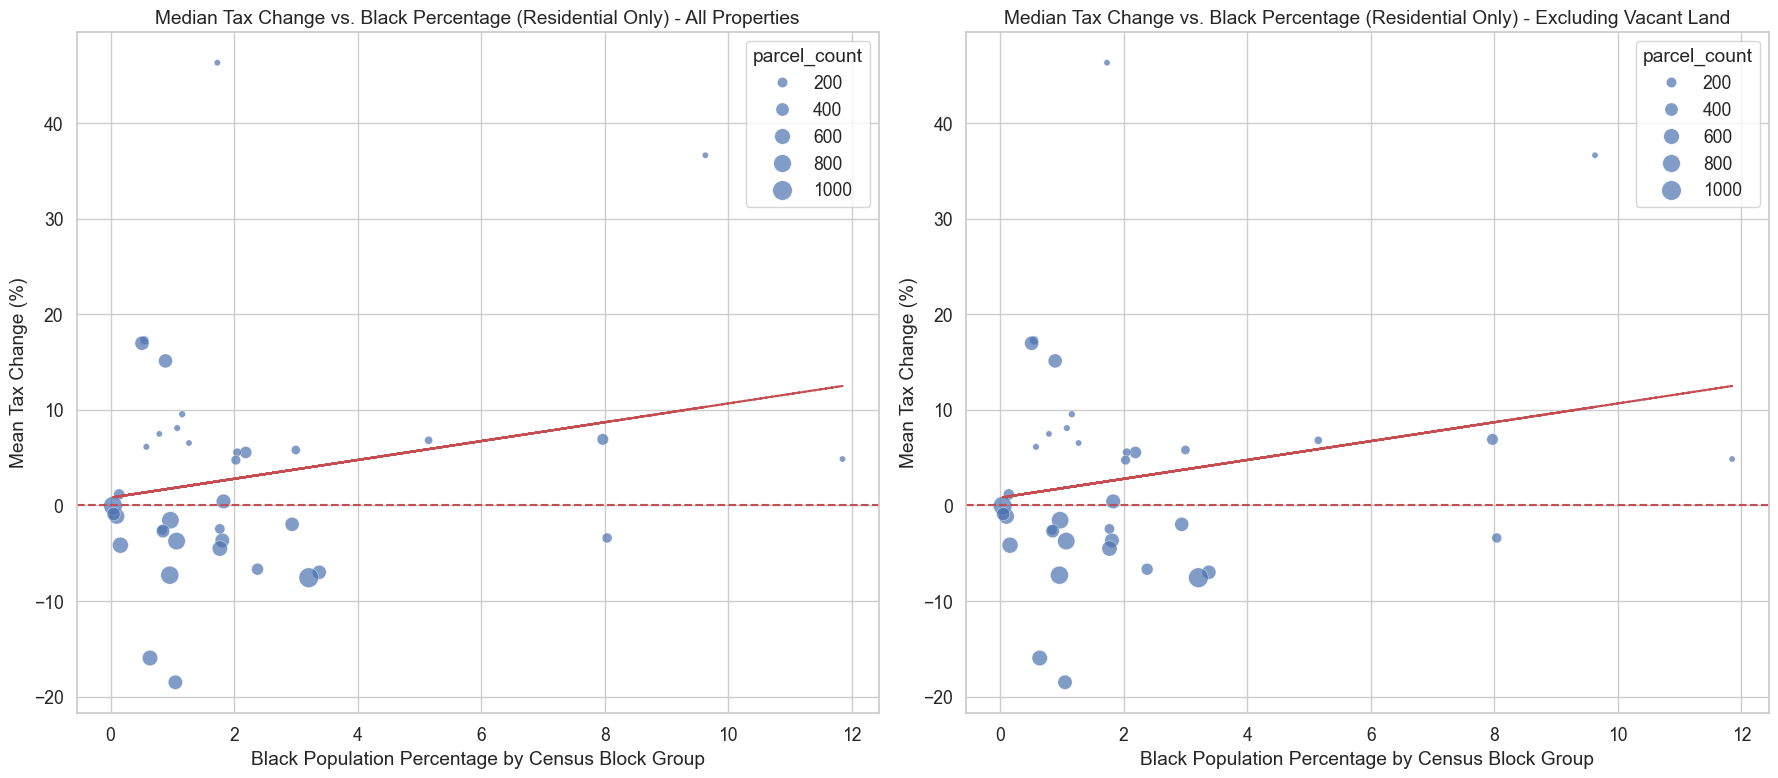

[Residential] Correlation income_mean_all: -0.0609
[Residential] Correlation income_median_all: -0.1055
[Residential] Correlation minority_mean_all: -0.0878
[Residential] Correlation black_mean_all: 0.2308
[Residential] Correlation income_mean_non_vacant: -0.0609
[Residential] Correlation income_median_non_vacant: -0.1055
[Residential] Correlation minority_mean_non_vacant: -0.0878
[Residential] Correlation black_mean_non_vacant: 0.2308


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: The default of observed=False is deprecated and will 


[Residential] Tax impact by income quintile (all properties):


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_82967/3291441258.py:118: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(


,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),6406.0,-4.534031,-2.262747,51142.547299
1,Q2,6072.0,-5.517784,-3.013389,80241.849802
2,Q3,6226.0,-6.160656,-3.181447,89357.773209
3,Q4,6536.0,-6.317853,-4.405213,103009.406518
4,Q5 (Highest),5835.0,-1.667328,-0.730322,126701.290831


...

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),6406.0,-4.534031,-2.262747,51142.547299
1,Q2,6072.0,-5.517784,-3.013389,80241.849802
2,Q3,6226.0,-6.160656,-3.181447,89357.773209
3,Q4,6536.0,-6.317853,-4.405213,103009.406518
4,Q5 (Highest),5835.0,-1.667328,-0.730322,126701.290831



[Residential] Tax impact by minority percentage quintile (all properties):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),6316.0,-2.871924,-0.103972,7.598520
1,Q2,6511.0,-2.488804,-1.303090,13.166351
2,Q3,6528.0,-6.590355,-4.456135,19.320080
3,Q4,5573.0,-6.607324,-4.262063,23.626095
4,Q5 (Highest),6147.0,-6.139491,-3.818296,38.471414



[Residential] Tax impact by minority percentage quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),6316.0,-2.871924,-0.103972,7.598520
1,Q2,6511.0,-2.488804,-1.303090,13.166351
2,Q3,6528.0,-6.590355,-4.456135,19.320080
3,Q4,5573.0,-6.607324,-4.262063,23.626095
4,Q5 (Highest),6147.0,-6.139491,-3.818296,38.471414


In [1096]:
# Restrict df to only residential property categories
residential_categories = [
    "Single Family",
    "Small Multi-Family (2-4 units)"
]
df_residential = df[df['PROPERTY_CATEGORY'].isin(residential_categories)].copy()

# --- Repeat the block group summary and quintile analysis for residential only ---

# Filter data for residential (positive income, non-vacant)
gdf_residential_filtered, non_vacant_residential_gdf = filter_data(df_residential)

# Calculate block group summaries (all with positive median_income only, residential only)
census_block_groups_res = calculate_block_group_summary(gdf_residential_filtered)
non_vacant_block_summary_res = calculate_block_group_summary(non_vacant_residential_gdf)

# Create comparison plots (all with positive median_income only, residential only)
plot_comparison(
    census_block_groups_res, non_vacant_block_summary_res, 
    'median_income', 'median_tax_change_pct', 
    'Median Tax Change vs. Median Income (Residential Only)', 
    'Median Income by Census Block Group ($)'
)

plot_comparison(
    census_block_groups_res, non_vacant_block_summary_res,
    'minority_pct', 'median_tax_change_pct',
    'Median Tax Change vs. Minority Percentage (Residential Only)',
    'Minority Population Percentage by Census Block Group'
)

plot_comparison(
    census_block_groups_res, non_vacant_block_summary_res,
    'black_pct', 'median_tax_change_pct',
    'Median Tax Change vs. Black Percentage (Residential Only)',
    'Black Population Percentage by Census Block Group'
)

# Calculate and print correlations (all with positive median_income only, residential only)
correlations_res = calculate_correlations(census_block_groups_res, non_vacant_block_summary_res)
for key, value in correlations_res.items():
    print(f"[Residential] Correlation {key}: {value:.4f}")

# Create and display quintile summaries (income quintiles exclude negative/zero incomes, residential only)
income_quintile_summary_res = create_quintile_summary(gdf_residential_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary_res = create_quintile_summary(non_vacant_residential_gdf, 'median_income', 'median_income')
minority_quintile_summary_res = create_quintile_summary(gdf_residential_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary_res = create_quintile_summary(non_vacant_residential_gdf, 'minority_pct', 'minority_pct')

print("\n[Residential] Tax impact by income quintile (all properties):")
display(income_quintile_summary_res)
print("\n[Residential] Tax impact by income quintile (excluding vacant land):")
display(non_vacant_income_quintile_summary_res)
print("\n[Residential] Tax impact by minority percentage quintile (all properties):")
display(minority_quintile_summary_res)
print("\n[Residential] Tax impact by minority percentage quintile (excluding vacant land):")
display(non_vacant_minority_quintile_summary_res)


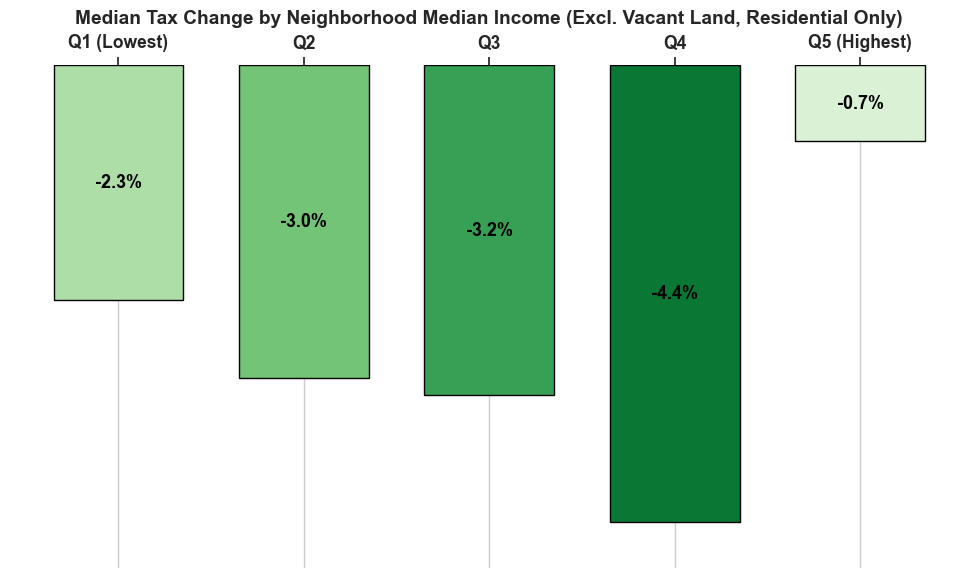

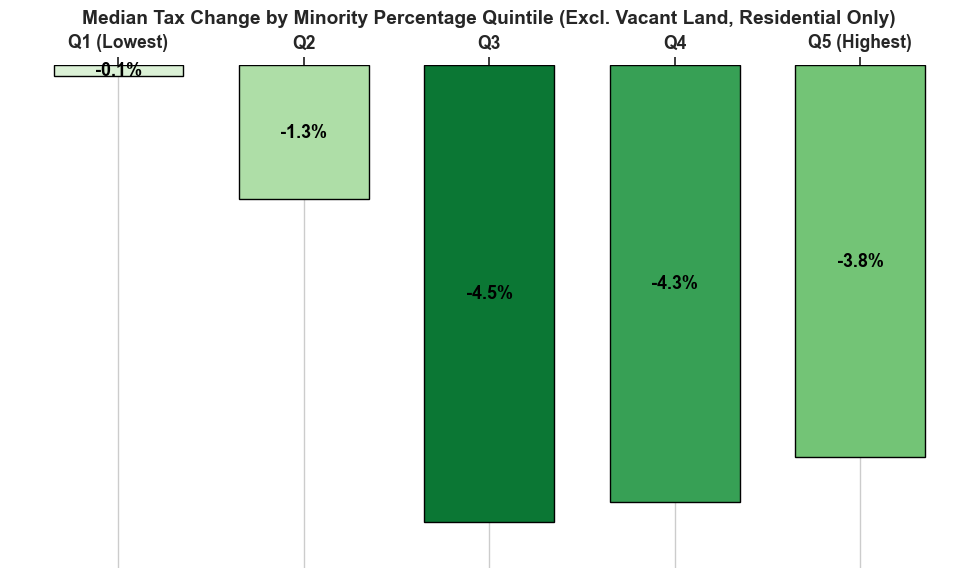

In [1097]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a modern style
sns.set_theme(style="whitegrid", font_scale=1.15)

# Upside Down Bar Graph: Median Tax Change by Neighborhood Median Income Excluding Vacant Land (Residential Only)
fig, ax = plt.subplots(figsize=(10, 6))

vals = non_vacant_income_quintile_summary_res['median_tax_change_pct']
labels = non_vacant_income_quintile_summary_res['median_income_quintile']

# Color mapping: dark green (more negative) to light green (less negative)
colors = sns.color_palette("Greens", n_colors=len(vals))
# Sort so that the most negative (largest magnitude) is darkest
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

# To make bars start at the top and go down, invert the y-axis and plot positive heights
bars = ax.bar(
    labels,
    np.abs(vals),
    color=color_map,
    edgecolor='black',
    width=0.7
)

# Invert the y-axis so bars start at the top and go down
ax.invert_yaxis()

# Remove y-axis
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Neighborhood Median Income (Excl. Vacant Land, Residential Only)', weight='bold', pad=30)

# Remove all spines (including bottom)
sns.despine(left=True, right=True, top=True, bottom=True)

# Add value labels (bold, % sign) centered inside each bar (no line below the bar)
for bar, val in zip(bars, vals):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

# Move x-tick labels to the top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

# Set y-limits to show bars going down from the top
ymax = np.abs(vals).max() * 1.1
ax.set_ylim(ymax, 0)

plt.tight_layout()
plt.show()

# Upside Down Bar Graph: Median Tax Change by Minority Percentage Quintile Excluding Vacant Land (Residential Only)
fig, ax = plt.subplots(figsize=(10, 6))

vals2 = non_vacant_minority_quintile_summary_res['median_tax_change_pct']
labels2 = non_vacant_minority_quintile_summary_res['minority_pct_quintile']

colors2 = sns.color_palette("Greens", n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]

bars2 = ax.bar(
    labels2,
    np.abs(vals2),
    color=color_map2,
    edgecolor='black',
    width=0.7
)

ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land, Residential Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)

for bar, val in zip(bars2, vals2):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

ymax2 = np.abs(vals2).max() * 1.1
ax.set_ylim(ymax2, 0)

plt.tight_layout()
plt.show()


In [1098]:
# Import our new policy analysis functions
import sys
sys.path.append('..')  # Add parent directory to path
from policy_analysis import (
    analyze_vacant_land, 
    analyze_parking_lots, 
    calculate_development_tax_penalty,
    print_vacant_land_summary,
    print_parking_analysis_summary, 
    print_development_penalty_summary
)


In [1099]:
## Policy Analysis: Vacant Land Speculation

# Filter out fully exempt properties for analysis
# Run vacant land analysis excluding fully exempt land
vacant_analysis = analyze_vacant_land(
    df=df,
    land_value_col='appraised_land_val',
    property_type_col='PROPERTY_CATEGORY', 
    neighborhood_col='nbhd_name',
    vacant_identifier='Vacant Land',
    improvement_value_col='appraised_improvement_val',
    exemption_col='exp_amt',
    exemption_flag_col='exp_flag'
)

# Print formatted summary
print_vacant_land_summary(vacant_analysis)


VACANT LAND ANALYSIS SUMMARY
Total vacant parcels: 4,850
Total vacant land value: $927,066,512
Average vacant land value: $191,148
Vacant land as % of total city land value: 6.7%


In [1100]:
## Policy Analysis: Parking Lot Efficiency

# Run parking lot analysis excluding fully exempt land
parking_analysis = analyze_parking_lots(
    df=df,
    land_value_col='appraised_land_val',
    improvement_value_col='appraised_improvement_val',
    property_type_col='PROPERTY_CATEGORY',
    parking_identifier='Transportation - Parking',
    min_land_value_threshold=50000,  # Focus on land worth $50k+
    max_improvement_ratio=0.1,  # Improvement value <= 10% of land value
    exemption_col='exp_amt',
    exemption_flag_col='exp_flag'
)

# Print formatted summary
print_parking_analysis_summary(parking_analysis)

# Show detailed breakdown by land value tier
if 'by_land_value_tier' in parking_analysis:
    print("\nDetailed breakdown by land value tier:")
    print(parking_analysis['by_land_value_tier'].to_string())


PARKING LOT EFFICIENCY ANALYSIS
Total parking lots: 75
Total parking land value: $34,240,800
Average parking land value: $456,544
Average improvement ratio: 4.4%

Underutilized parking lots (Land value >= $50,000 and improvement ratio <= 10.0%):
Count: 66
Total land value: $30,257,180
Average land value: $458,442

Development potential:
Current improvement value: $853,373
Potential improvement value: $43,442,135
Untapped development value: $42,588,762

Detailed breakdown by land value tier:
                 count  total_land_value  avg_land_value  avg_improvement_ratio
land_value_tier                                                                
<$25k                1           13161.0       13161.000                  0.000
$25k-$50k            0               0.0             NaN                    NaN
$50k-$100k           1           79462.0       79462.000                  0.000
$100k-$250k         24         4482527.0      186771.958                  0.048
>$250k              49  

/Users/gregmiller/Documents/CLE/cle/LVTShift/examples/../policy_analysis.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_analysis = tier_df.groupby('land_value_tier').agg({


In [1101]:
# Import new property analysis functions
from policy_analysis import (
    analyze_property_values_by_category, 
    print_property_values_summary
)


In [1102]:
## Property Value Analysis by Category

# Analyze property values by category including exemptions
property_values = analyze_property_values_by_category(
    df=df,
    category_col='PROPERTY_CATEGORY', 
    land_value_col='appraised_land_val',
    improvement_value_col='appraised_improvement_val',
    exemption_col='exp_amt',
    exemption_flag_col='exp_flag'
)

# Print formatted summary
print_property_values_summary(property_values, "Bellingham Property Values by Category")


BELLINGHAM PROPERTY VALUES BY CATEGORY
             PROPERTY_CATEGORY total_land_value  property_count total_improvement_value improvement_land_ratio total_exemptions non_exempt_land_value non_exempt_improvement_value non_exempt_improvement_land_ratio  fully_exempt_count
                 Single Family   $9,745,722,409           30163         $13,296,932,935                   1.36     $303,876,527        $9,718,124,203              $13,020,654,614                              1.34                 NaN
     Retail/Service/Commercial     $996,450,318            1158          $1,801,118,096                   1.81      $99,481,448          $981,673,873               $1,716,625,030                              1.75                 NaN
                   Vacant Land     $927,820,398            4850             $25,735,132                   0.03       $1,064,952          $927,066,512                  $25,424,066                              0.03                 NaN
 Large Multi-Family (5+ units

In [1103]:
# Land value by improvement share categories (non-exempt basis)
from policy_analysis import analyze_land_by_improvement_share

# Run for all parcels
share_summary = analyze_land_by_improvement_share(
    df=df,
    land_value_col='appraised_land_val',
    improvement_value_col='appraised_improvement_val',
    exemption_col='exp_amt',
    exemption_flag_col='exp_flag'
)

print("Adjusted total land value (non-exempt): ${:,.0f}".format(share_summary['total_adjusted_land_value']))
for row in share_summary['categories']:
    print("- {}: {:,} parcels | Adjusted land: ${:,.0f} ({:.1f}%)".format(
        row['category'], row['parcel_count'], row['adjusted_land_value'], row['share_of_total_land_value_pct']
    ))

# Now exclude vacant land and parking lots using PROPERTY_CATEGORY
exclude_categories = ["Vacant Land", "Transportation - Parking"]
df_non_vacant = df[~df["PROPERTY_CATEGORY"].isin(exclude_categories)]

share_summary_non_vacant = analyze_land_by_improvement_share(
    df=df_non_vacant,
    land_value_col='appraised_land_val',
    improvement_value_col='appraised_improvement_val',
    exemption_col='exp_amt',
    exemption_flag_col='exp_flag'
)

print("\n(Excluding Vacant Land and Transportation - Parking)")
print("Adjusted total land value (non-exempt, non-vacant): ${:,.0f}".format(share_summary_non_vacant['total_adjusted_land_value']))
for row in share_summary_non_vacant['categories']:
    print("- {}: {:,} parcels | Adjusted land: ${:,.0f} ({:.1f}%)".format(
        row['category'], row['parcel_count'], row['adjusted_land_value'], row['share_of_total_land_value_pct']
    ))


Adjusted total land value (non-exempt): $13,760,390,258
- 0% improvement: 4,815 parcels | Adjusted land: $906,147,348 (6.6%)
- <10% improvement (excl. 0%): 391 parcels | Adjusted land: $202,294,670 (1.5%)
- 10-25% improvement: 717 parcels | Adjusted land: $470,265,142 (3.4%)
- 25-50% improvement: 7,556 parcels | Adjusted land: $3,689,762,850 (26.8%)

(Excluding Vacant Land and Transportation - Parking)
Adjusted total land value (non-exempt, non-vacant): $12,799,082,946
- 0% improvement: 0 parcels | Adjusted land: $0 (0.0%)
- <10% improvement (excl. 0%): 321 parcels | Adjusted land: $170,984,975 (1.3%)
- 10-25% improvement: 708 parcels | Adjusted land: $461,299,744 (3.6%)
- 25-50% improvement: 7,550 parcels | Adjusted land: $3,684,725,347 (28.8%)


In [1104]:
print(output_summary)

                 PROPERTY_CATEGORY  total_tax_change_dollars  property_count  \
8                    Single Family              8.866027e+04           30163   
12                     Vacant Land              4.772772e+06            4850   
9   Small Multi-Family (2-4 units)             -2.409201e+05            1182   
7        Retail/Service/Commercial             -1.514909e+05            1158   
4                 Mobile Home Park              4.763733e+05            1027   
6                Other Residential             -8.087641e+05             977   
2    Large Multi-Family (5+ units)             -1.585426e+06             419   
5                            Other              1.111341e+05             403   
0                     Condominiums             -2.670126e+06             364   
3         Manufacturing/Industrial             -3.872825e+04             253   
10        Transportation - Parking              1.677225e+05              75   
1                Designated Forest      

In [1105]:
import pandas as pd

df["land_value"] = df["appraised_land_val"]
df["improvement_value"] = df["appraised_improvement_val"]
df["assessed_amt"] = df["appraised_val_total"]

# Calculate square footage for each parcel
# Prioritize projected area, else geometry (with explicit CRS handling)
if 'Shape__Area' in df.columns:
    df['sqft'] = df['Shape__Area'] * 10.7639
else:
    # Check if geometry is georeferenced in degrees (EPSG:4326 common for US)
    # Reproject to a projected CRS if necessary (using UTM based on centroid)
    try:
        import geopandas as gpd
        if hasattr(df, "geometry"):
            gdf = df if isinstance(df, gpd.GeoDataFrame) else gpd.GeoDataFrame(df, geometry="geometry")
            # If in geographic CRS, reproject to EPSG:32610 (UTM zone 10N) for Bellingham, WA
            if gdf.crs is not None and gdf.crs.is_geographic:
                gdf = gdf.to_crs(32610)  # UTM zone 10N, units = meters
            elif gdf.crs is None:
                # Assume input is not already correctly projected; assign and convert
                gdf.set_crs(epsg=4326, inplace=True)
                gdf = gdf.to_crs(32610)
            # Use meters, convert to square feet
            df['sqft'] = gdf.geometry.area * 10.7639
        else:
            # Fallback: treat geometry as projected meters (warn user)
            df['sqft'] = df.geometry.area * 10.7639
    except Exception as e:
        print(f"WARNING: Could not reproject geometry for accurate area calculation; falling back to raw area. Error: {e}")
        df['sqft'] = df.geometry.area * 10.7639  # fallback (possibly inaccurate)

# Avoid division by zero
df['sqft'] = df['sqft'].replace(0, pd.NA)

# Calculate per square foot columns
df['land_value_per_sqft'] = df['land_value'] / df['sqft']
df['assessed_amt_per_sqft'] = df['assessed_amt'] / df['sqft']
df['improvement_value_per_sqft'] = df['improvement_value'] / df['sqft']
df['tax_change_per_sqft'] = df['tax_change'] / df['sqft']
df['new_tax_per_sqft'] = df['new_tax'] / df['sqft']
df['current_tax_per_sqft'] = df['current_tax'] / df['sqft']

# Ensure geometry is attached and select columns to save
columns_to_save = [
    'tax_change_pct', 'tax_change', 'new_tax', 'current_tax', 'PID_NUM', 
    'PROPERTY_CATEGORY', 'nbhd_code', 'prop_use_desc', 'site_address', 
    'assessed_amt', 'land_value', 'improvement_value',  'geometry',
    'sqft', 'land_value_per_sqft', 'assessed_amt_per_sqft', 'improvement_value_per_sqft',
    'tax_change_per_sqft', 'new_tax_per_sqft', 'current_tax_per_sqft'
]

# Save the DataFrame with geometry as a parquet file (restricted columns)
df[columns_to_save].to_parquet('bellingham_full_geom.parquet', index=False)

# Also save the full DataFrame with geometry as a parquet file (all columns)
df.to_parquet('bellingham_full_geom_fullcols.parquet', index=False)


KeyError: "['PID_NUM', 'nbhd_code', 'prop_use_desc', 'site_address'] not in index"

In [1106]:
# Check if all geometries are Polygon or MultiPolygon and print the result
is_all_polygons = df.geometry.geom_type.isin(['Polygon', 'MultiPolygon']).all()
print(f"All geometries are Polygon or MultiPolygon: {is_all_polygons}")
if not is_all_polygons:
    # Try to convert to polygons if possible
    df = df[df.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()


All geometries are Polygon or MultiPolygon: True


In [1107]:

# Define "underdeveloped" as: non-exempt and improvement_value / assessed_amt < 0.5
# "Vacant" properties: PROPERTY_CATEGORY contains "vacant" (case-insensitive)
# "Non-exempt": new_exemption is null/None/NaN or 0

# 1. Vacant properties
vacant_mask = df['PROPERTY_CATEGORY'].str.lower().str.contains('vacant', na=False)

# 3. Underdeveloped: improvement_value / assessed_amt < 0.5
underdeveloped_mask = (df['improvement_value'] / df['assessed_amt'] < 0.75)

# Report the number of parcels that are vacant and number that are underdeveloped
n_vacant = vacant_mask.sum()
n_underdeveloped = underdeveloped_mask.sum()
print(f"Number of vacant parcels: {n_vacant}")
print(f"Number of underdeveloped parcels: {n_underdeveloped}")

# Combine: vacant OR underdeveloped
target_mask = vacant_mask | underdeveloped_mask

# Calculate for target group
target_df = df[target_mask]
other_df = df[~target_mask]

# Results for target group
total_tax_change_target = target_df['tax_change'].sum()
median_pct_target = target_df['tax_change_pct'].median()
n_target = len(target_df)
n_target_increase = (target_df['tax_change'] > 0).sum()
n_target_decrease = (target_df['tax_change'] < 0).sum()
pct_target_increase = 100 * n_target_increase / n_target if n_target > 0 else float('nan')
pct_target_decrease = 100 * n_target_decrease / n_target if n_target > 0 else float('nan')

# Results for all other parcels
total_tax_change_other = other_df['tax_change'].sum()
median_pct_other = other_df['tax_change_pct'].median()
n_other = len(other_df)
n_other_increase = (other_df['tax_change'] > 0).sum()
n_other_decrease = (other_df['tax_change'] < 0).sum()
pct_other_increase = 100 * n_other_increase / n_other if n_other > 0 else float('nan')
pct_other_decrease = 100 * n_other_decrease / n_other if n_other > 0 else float('nan')

print("Vacant or Underdeveloped Parcels:")
print(f"  Total Tax Change ($): {total_tax_change_target:,.2f}")
print(f"  Median Tax Change (%): {median_pct_target:.2f}")
print(f"  Parcels with Tax Increase: {pct_target_increase:.1f}%")
print(f"  Parcels with Tax Decrease: {pct_target_decrease:.1f}%")

print("\nAll Other Parcels:")
print(f"  Total Tax Change ($): {total_tax_change_other:,.2f}")
print(f"  Median Tax Change (%): {median_pct_other:.2f}")
print(f"  Parcels with Tax Increase: {pct_other_increase:.1f}%")
print(f"  Parcels with Tax Decrease: {pct_other_decrease:.1f}%")


Number of vacant parcels: 4850
Number of underdeveloped parcels: 37799
Vacant or Underdeveloped Parcels:
  Total Tax Change ($): 9,477,590.59
  Median Tax Change (%): 0.40
  Parcels with Tax Increase: 51.2%
  Parcels with Tax Decrease: 48.8%

All Other Parcels:
  Total Tax Change ($): -9,477,590.59
  Median Tax Change (%): -24.29
  Parcels with Tax Increase: 0.0%
  Parcels with Tax Decrease: 100.0%


In [1109]:

# --- Export spokane.parquet with same columns as Syracuse ---
import os
import numpy as np

# Create export dataframe
export_gdf = df.copy()

# Create exemption flag as binary (1/0) for fully exempt properties
export_gdf['exemption_flag'] = (export_gdf['exp_flag'] == True).astype(int)
print("Number of exemption flags (fully exempt properties):", export_gdf['exemption_flag'].sum())

# Map property category (use existing PROPERTY_CATEGORY column)
export_gdf['property_land_use_category'] = export_gdf['PROPERTY_CATEGORY']

# Create refined property/land use category with three options: Vacant, Parking Lot, Underdeveloped
def categorize_property_refined(row):
    """Categorize properties into refined categories"""
    category = row['PROPERTY_CATEGORY']
    if 'Vacant' in str(category):
        return 'Vacant'
    elif 'Parking' in str(category):
        return 'Parking Lot'
    elif row['improvement_value'] < 0.5 * (row['land_value'] + row['improvement_value']):
        return 'Underdeveloped'
    else:
        return None  # null for all other categories

export_gdf['property_land_use_refined'] = export_gdf.apply(categorize_property_refined, axis=1)

if 'Shape__Area' in df.columns:
    df['area_sqft'] = df['Shape__Area'] * 10.7639
else:
    # Check if geometry is georeferenced in degrees (EPSG:4326 common for US)
    # Reproject to a projected CRS if necessary (using UTM based on centroid)
    try:
        import geopandas as gpd
        if hasattr(df, "geometry"):
            gdf = df if isinstance(df, gpd.GeoDataFrame) else gpd.GeoDataFrame(df, geometry="geometry")
            # If in geographic CRS, reproject to EPSG:32610 (UTM zone 10N) for Bellingham, WA
            if gdf.crs is not None and gdf.crs.is_geographic:
                gdf = gdf.to_crs(32610)  # UTM zone 10N, units = meters
            elif gdf.crs is None:
                # Assume input is not already correctly projected; assign and convert
                gdf.set_crs(epsg=4326, inplace=True)
                gdf = gdf.to_crs(32610)
            # Use meters, convert to square feet
            df['area_sqft'] = gdf.geometry.area * 10.7639
        else:
            # Fallback: treat geometry as projected meters (warn user)
            df['area_sqft'] = df.geometry.area * 10.7639
    except Exception as e:
        print(f"WARNING: Could not reproject geometry for accurate area calculation; falling back to raw area. Error: {e}")
        df['area_sqft'] = df.geometry.area * 10.7639  # fallback (possibly inaccurate)

# Calculate current tax per square foot
export_gdf['current_tax_per_sqft'] = np.where(
    export_gdf['area_sqft'] > 0,
    export_gdf['current_tax'] / export_gdf['area_sqft'],
    0
)

# Calculate land value per square foot
export_gdf['land_value_per_sqft'] = np.where(
    export_gdf['area_sqft'] > 0,
    export_gdf['land_value'] / export_gdf['area_sqft'],
    0
)

# Calculate improvement value per square foot
export_gdf['improvement_value_per_sqft'] = np.where(
    export_gdf['area_sqft'] > 0,
    export_gdf['improvement_value'] / export_gdf['area_sqft'],
    0
)

# Select columns for export, matching Syracuse structure
columns_to_export = [
    'geometry',
    'exemption_flag',
    'property_land_use_category',
    'property_land_use_refined',
    'current_tax',
    'current_tax_per_sqft',
    'land_value',
    'land_value_per_sqft',
    'improvement_value',
    'improvement_value_per_sqft'
]

# Rename columns to match Syracuse naming convention
export_final = export_gdf[columns_to_export].rename(columns={
    'land_value': 'current_full_land_value'
})

# Ensure geometry is valid
export_final['geometry'] = export_final['geometry'].apply(lambda geom: geom if geom is None or geom.is_valid else geom.buffer(0))

# Ensure output is in WGS84 (EPSG:4326) before saving
if export_final.crs is None or export_final.crs.to_epsg() != 4326:
    export_final = export_final.to_crs("EPSG:4326")
    print("Converted to EPSG:4326")

# Save as Parquet
output_filename = os.path.expanduser("~/Downloads/bellingham.parquet")
export_final.to_parquet(output_filename, index=False)

print(f"\n✅ Saved spokane.parquet to Downloads")
print("Saved columns:", export_final.columns.tolist())
print("Property refined category counts:")
print(export_final['property_land_use_refined'].value_counts(dropna=False))
print("Property category counts:")
print(export_final['property_land_use_category'].value_counts().head(10))

# Display first few rows
print(f"\n👀 First 5 rows of exported data:")
display(export_final.head())

Number of exemption flags (fully exempt properties): 0

✅ Saved spokane.parquet to Downloads
Saved columns: ['geometry', 'exemption_flag', 'property_land_use_category', 'property_land_use_refined', 'current_tax', 'current_tax_per_sqft', 'current_full_land_value', 'land_value_per_sqft', 'improvement_value', 'improvement_value_per_sqft']
Property refined category counts:
property_land_use_refined
None              27517
Underdeveloped     8579
Vacant             4850
Parking Lot          75
Name: count, dtype: int64
Property category counts:
property_land_use_category
Single Family                     30163
Vacant Land                        4850
Small Multi-Family (2-4 units)     1182
Retail/Service/Commercial          1158
Mobile Home Park                   1027
Other Residential                   977
Large Multi-Family (5+ units)       419
Other                               403
Condominiums                        364
Manufacturing/Industrial            253
Name: count, dtype: int64



,geometry,exemption_flag,property_land_use_category,property_land_use_refined,current_tax,current_tax_per_sqft,current_full_land_value,land_value_per_sqft,improvement_value,improvement_value_per_sqft
18,"POLYGON ((-122.6276 48.77575, -122.62759 48.77...",0,Vacant Land,Vacant,11.819277,0.000014,1869.0,0.002216,0.0,0.0
23,"POLYGON ((-122.62896 48.77935, -122.62782 48.7...",0,Vacant Land,Vacant,28.055028,0.000017,3649.0,0.002192,0.0,0.0
57,"POLYGON ((-122.63861 48.78296, -122.6414 48.78...",0,Vacant Land,Vacant,1.568315,0.000003,248.0,0.000396,0.0,0.0
58,"POLYGON ((-122.63306 48.78382, -122.63861 48.7...",0,Vacant Land,Vacant,1.429190,0.000002,226.0,0.000383,0.0,0.0
63,"POLYGON ((-122.63304 48.78655, -122.63304 48.7...",0,Vacant Land,Vacant,298.523696,0.000613,47206.0,0.096901,0.0,0.0
